<a href="https://www.kaggle.com/code/avikdas567/organic-laser-emitters-dft-driven-qspr-benchmark?scriptVersionId=348569211" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Closed-Loop Discovery of Organic Solid-State Laser Emitters
## Photophysical Feature Engineering, Quantitative Structure-Property Relationships, and Predictive Benchmarking

---

# 1. Scientific Context & Photophysical Foundations
Solid-state organic dye lasers require gain media characterized by high stimulated emission cross sections $\sigma_{\text{em}}$, high photoluminescence quantum yields $\Phi_{\text{PL}}$, and minimal non-radiative deactivation rates $k_{\text{nr}}$. This study evaluates the experimental and density functional theory (DFT/TD-DFT) datasets derived from the closed-loop exploration of modular organic dye architectures reported by Roch et al. (*Science* 2024, 384, adk9227).

The target molecules are constructed modularly via combinations of **32 Core**, **42 Bridge**, and **160 Cap** building blocks. The primary photophysical figure of merit for achieving low amplified spontaneous emission (ASE) thresholds is the net stimulated emission gain cross section $\sigma_{\text{em}}$ (expressed in $\text{cm}^2$):

$$\sigma_{\text{em}}(\lambda) = \frac{\lambda^4 E(\lambda)}{8 \pi c n^2 \tau_{\text{rad}}} = \frac{\lambda^4 E(\lambda) \Phi_{\text{PL}}}{8 \pi c n^2 \tau}$$

where:
- $E(\lambda)$ is the normalized fluorescence emission spectral lineshape ($\int E(\lambda) d\lambda = 1$),
- $c$ is the speed of light in vacuum,
- $n$ is the refractive index of the host medium,
- $\tau$ is the experimental excited-state lifetime measured via time-correlated single-photon counting (TCSPC),
- $\tau_{\text{rad}} = \tau / \Phi_{\text{PL}}$ is the radiative lifetime.

The integrated spectral gain factor $\gamma$ (in $\text{cm}^2 \cdot \text{s}$) weights emission intensity across wavelength, strongly penalizing short-wavelength emitters:

$$\gamma = \int \sigma_{\text{em}}(\lambda) d\lambda$$

Competing non-radiative relaxation mechanisms dictate deactivation kinetics:

$$k_{\text{rad}} = \frac{\Phi_{\text{PL}}}{\tau}, \quad k_{\text{nr}} = \frac{1 - \Phi_{\text{PL}}}{\tau}$$

The original literature benchmark reported significant challenges in out-of-fold generalization, obtaining a 3-fold cross-validated $R^2 \le 0.46$. Below, we establish an end-to-end, reproducible, leakage-free pipeline integrating quantum-chemical descriptors, non-linear feature representations, and ensemble regression models to model and predict $\log_{10}(\sigma_{\text{em}})$.

In [1]:
# Deterministic runtime initialization and warning suppression
import os
import sys
import random
import warnings

# Suppress all runtime and future warnings
warnings.filterwarnings('ignore')
os.environ['PYTHONWARNINGS'] = 'ignore'
os.environ['PYTHONHASHSEED'] = '42'

import numpy as np
import pandas as pd
import scipy.stats as stats

# Set deterministic seeds
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Scientific plotting configuration
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['axes.edgecolor'] = '#2b2b2b'
plt.rcParams['grid.alpha'] = 0.35
plt.rcParams['grid.linestyle'] = '--'
sns.set_palette("deep")

# Scikit-Learn components
from sklearn.model_selection import KFold, RepeatedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Ridge, HuberRegressor
from sklearn.kernel_ridge import KernelRidge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor, StackingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.inspection import permutation_importance

print("Execution environment successfully initialized with strict determinism (Seed = 42).")

Execution environment successfully initialized with strict determinism (Seed = 42).


# 2. Dataset Ingestion and Schema Audit
We load the experimental dataset containing 476 characterized dye compounds alongside sanitized TD-DFT calculated properties and monomer libraries.

In [2]:
# File paths
DFT_PATH = "/kaggle/input/datasets/dfriday/organic-laser-emitters/DFTdata_Sanitized.csv"
EXP_PATH = "/kaggle/input/datasets/dfriday/organic-laser-emitters/Experimental_476_FullDFT.csv"
BRIDGE_PATH = "/kaggle/input/datasets/dfriday/organic-laser-emitters/bridge_building_blocks.csv"
CAP_PATH = "/kaggle/input/datasets/dfriday/organic-laser-emitters/cap_building_blocks.csv"
CORE_PATH = "/kaggle/input/datasets/dfriday/organic-laser-emitters/core_building_blocks.csv"

# Ingestion: header=1 aligns headers with the true property labels on line 1
df_exp = pd.read_csv(EXP_PATH, header=1)
df_dft_all = pd.read_csv(DFT_PATH)
df_bridge = pd.read_csv(BRIDGE_PATH)
df_cap = pd.read_csv(CAP_PATH)
df_core = pd.read_csv(CORE_PATH)

# Normalize column names to strip leading/trailing whitespaces
for df in [df_exp, df_dft_all, df_bridge, df_cap, df_core]:
    df.columns = df.columns.str.strip()

print(f"Experimental Dataset Shape   : {df_exp.shape}")
print(f"DFT Virtual Library Shape     : {df_dft_all.shape}")
print(f"Building Blocks (Core/Bridge/Cap) : {len(df_core)} / {len(df_bridge)} / {len(df_cap)}")

# Identify primary experimental columns
target_candidates = [
    'Gain Cross Section (cm^2)',
    'Spectral Gain Factor (cm^2 s)',
    'Quantum Yield',
    'Emission Lifetime (ns)',
    'Absorption Wavelength (nm)',
    'Emission Wavelength (nm)'
]

exp_summary = df_exp[target_candidates].describe().T[['count', 'mean', 'std', 'min', '50%', 'max']]
exp_summary.columns = ['Count', 'Mean', 'Std Dev', 'Min', 'Median', 'Max']
exp_summary

Experimental Dataset Shape   : (476, 258)
DFT Virtual Library Shape     : (182779, 253)
Building Blocks (Core/Bridge/Cap) : 161 / 68 / 42


,Count,Mean,Std Dev,Min,Median,Max
Gain Cross Section (cm^2),476.0,4.266614e-17,5.784369e-17,1.100000e-20,1.700000e-17,3.140000e-16
Spectral Gain Factor (cm^2 s),286.0,6.014720e-25,1.853168e-25,1.060000e-25,5.850000e-25,1.480000e-24
Quantum Yield,476.0,2.474830e-01,2.761370e-01,1.000204e-03,1.363834e-01,9.974981e-01
Emission Lifetime (ns),350.0,1.940999e+00,1.494999e+00,3.856364e-01,1.502582e+00,1.118605e+01
Absorption Wavelength (nm),476.0,3.192987e+02,2.840515e+01,3.001891e+02,3.001891e+02,4.196074e+02
Emission Wavelength (nm),350.0,4.541087e+02,5.071800e+01,3.854421e+02,4.482265e+02,6.570166e+02


# 3. Exploratory Photophysical Data Analysis
Gain cross section values span several orders of magnitude ($10^{-17}$ to $10^{-15} \text{ cm}^2$). Fitting linear loss functions on raw cross-section scales introduces severe heteroscedasticity and bias toward extreme outliers. Therefore, we define the regression target in logarithmic space:

$$y = \log_{10}(\sigma_{\text{em}})$$

We also compute experimental photophysical quantities:
- Stokes Shift in wavenumbers:
$$\Delta \bar{\nu} = \left(\frac{1}{\lambda_{\text{abs}}} - \frac{1}{\lambda_{\text{em}}}\right) \times 10^7 \text{ cm}^{-1}$$
- Radiative rate constant: $k_{\text{rad}} = \Phi_{\text{PL}} / \tau$
- Non-radiative rate constant: $k_{\text{nr}} = (1 - \Phi_{\text{PL}}) / \tau$

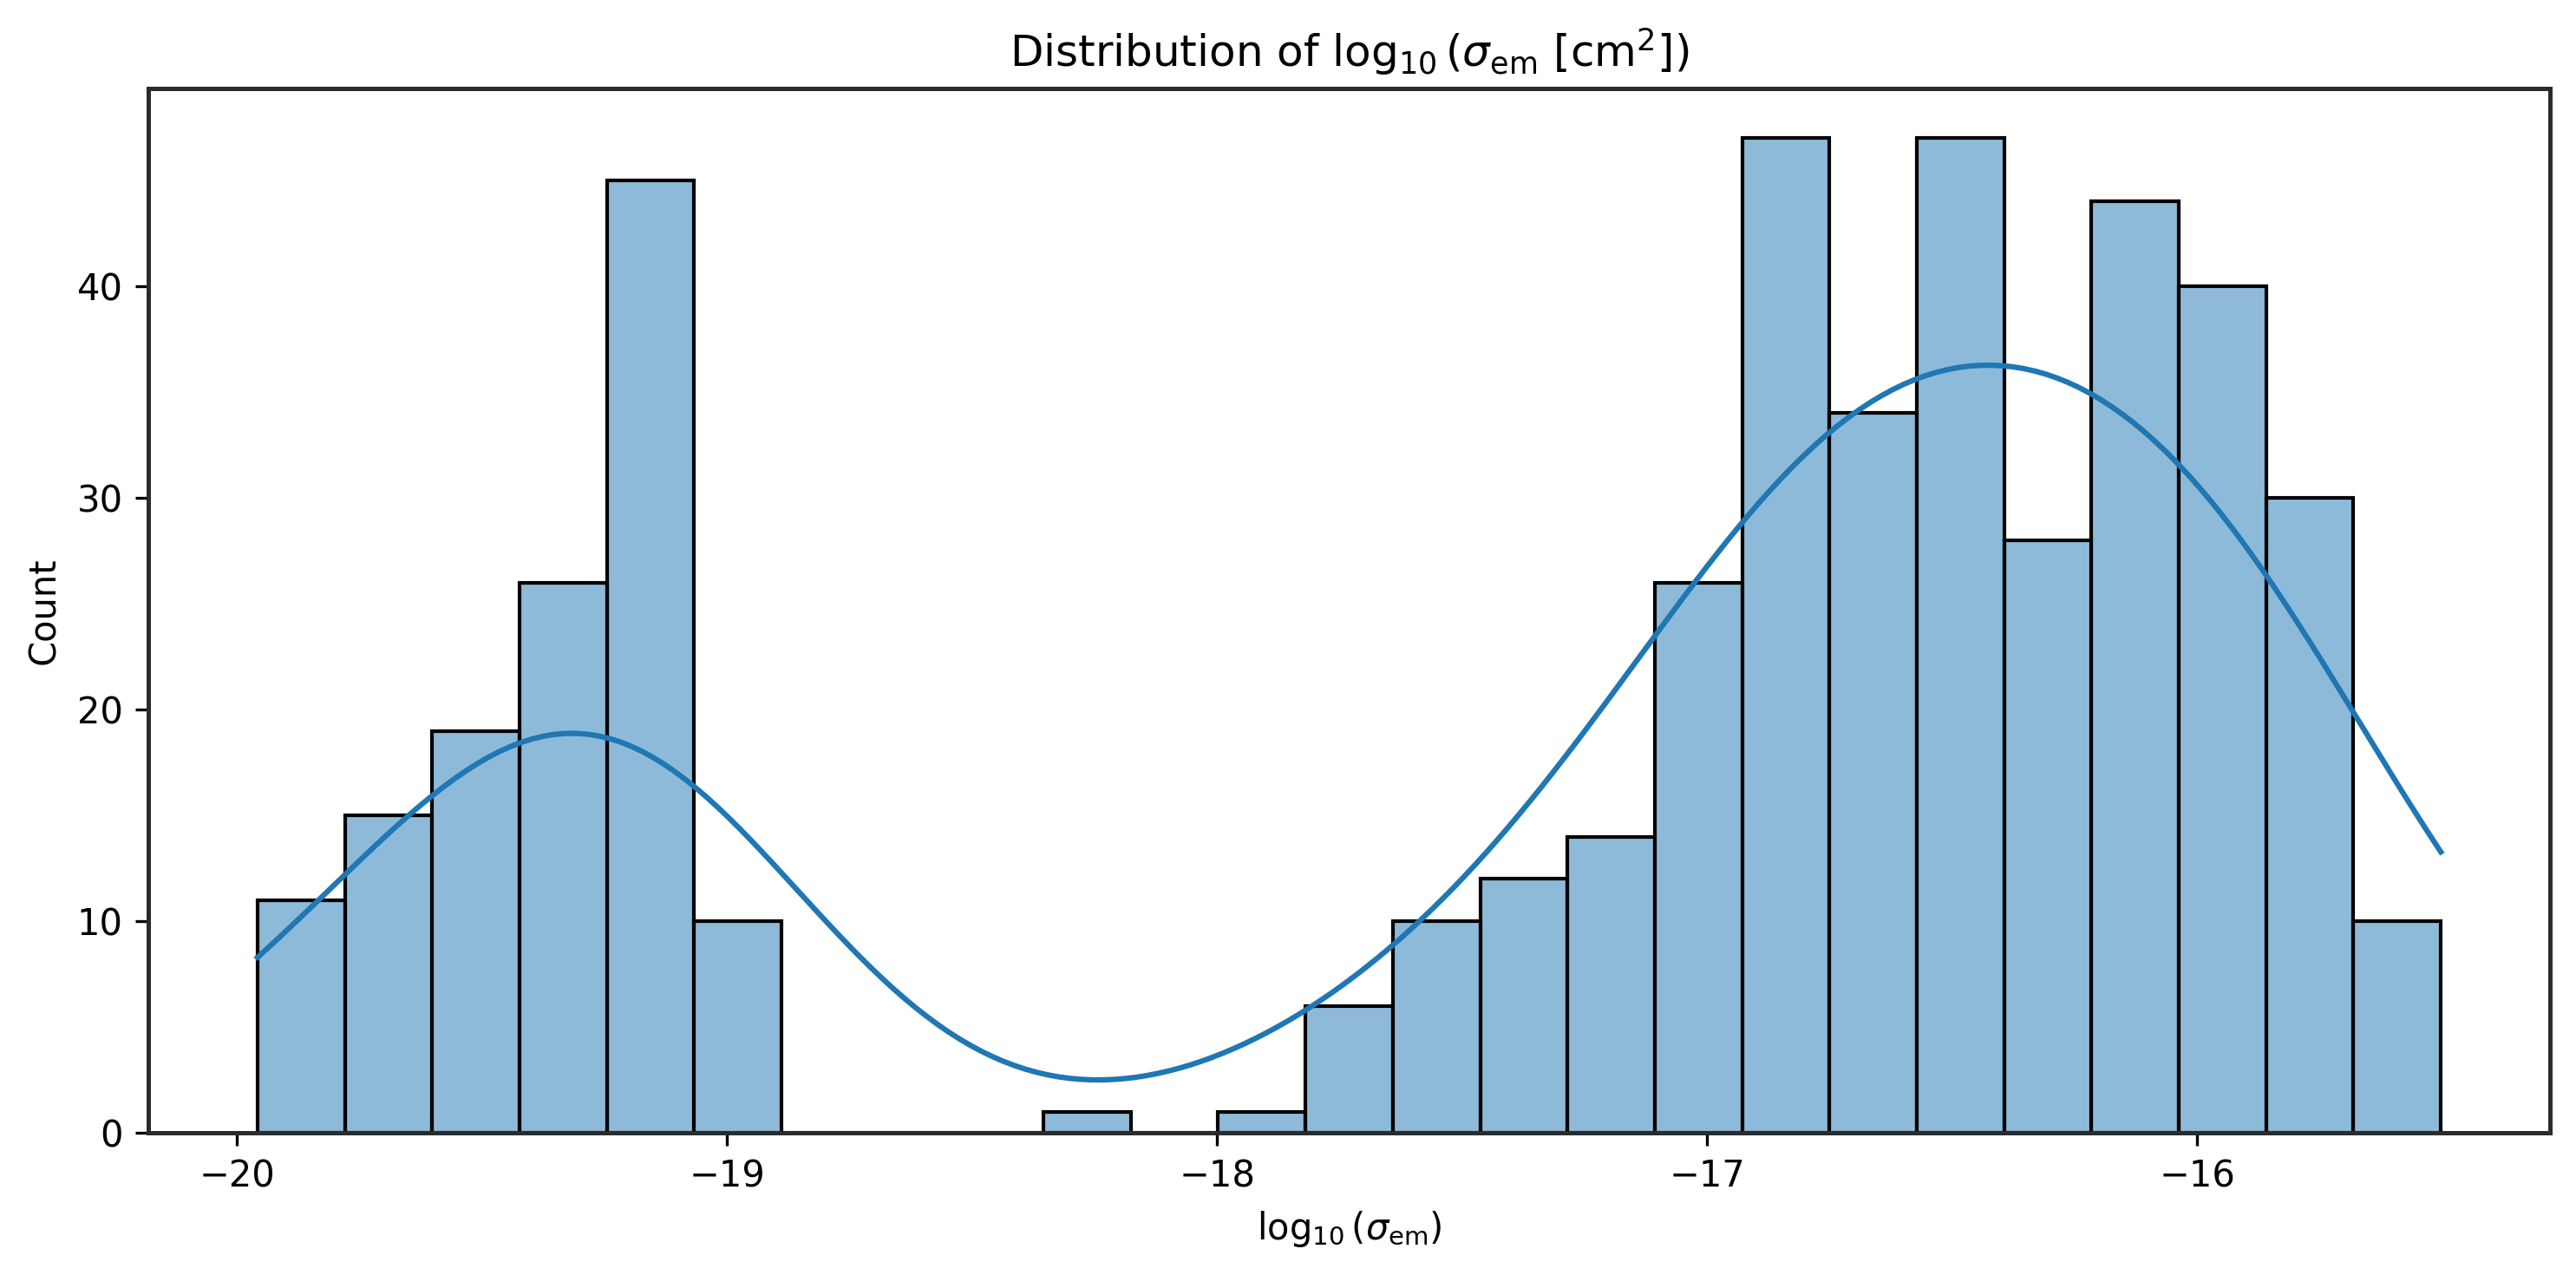

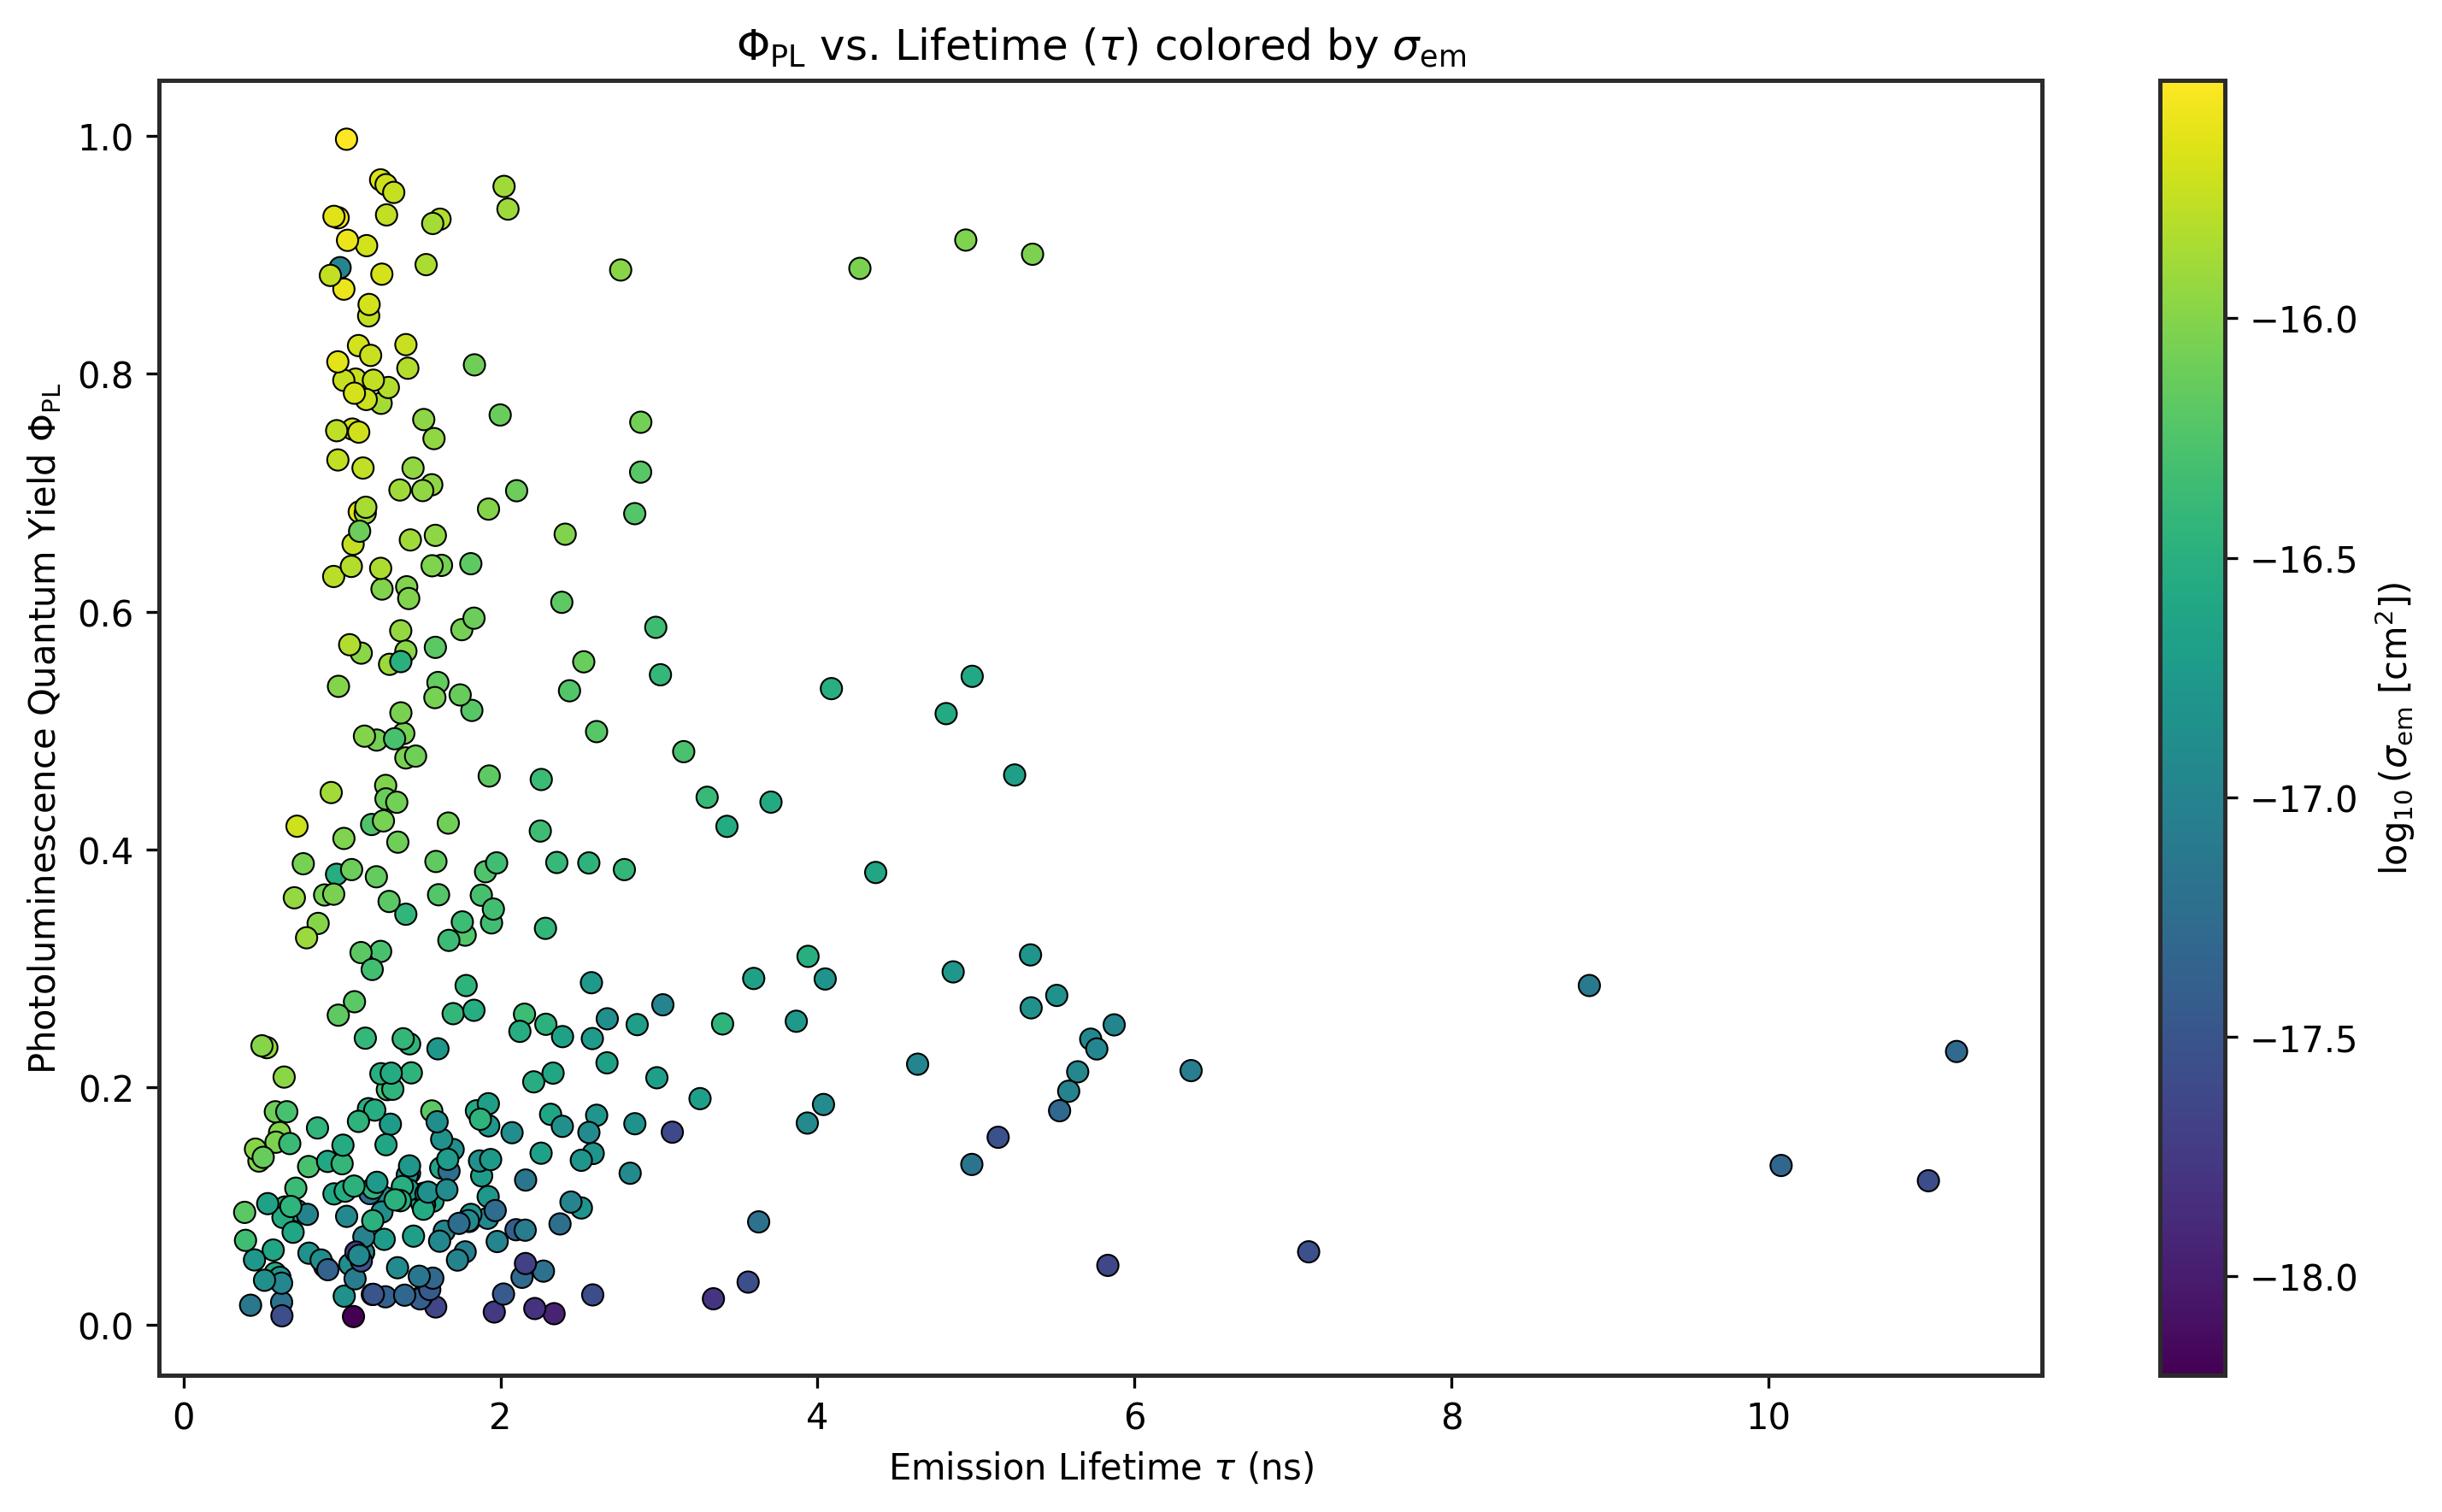

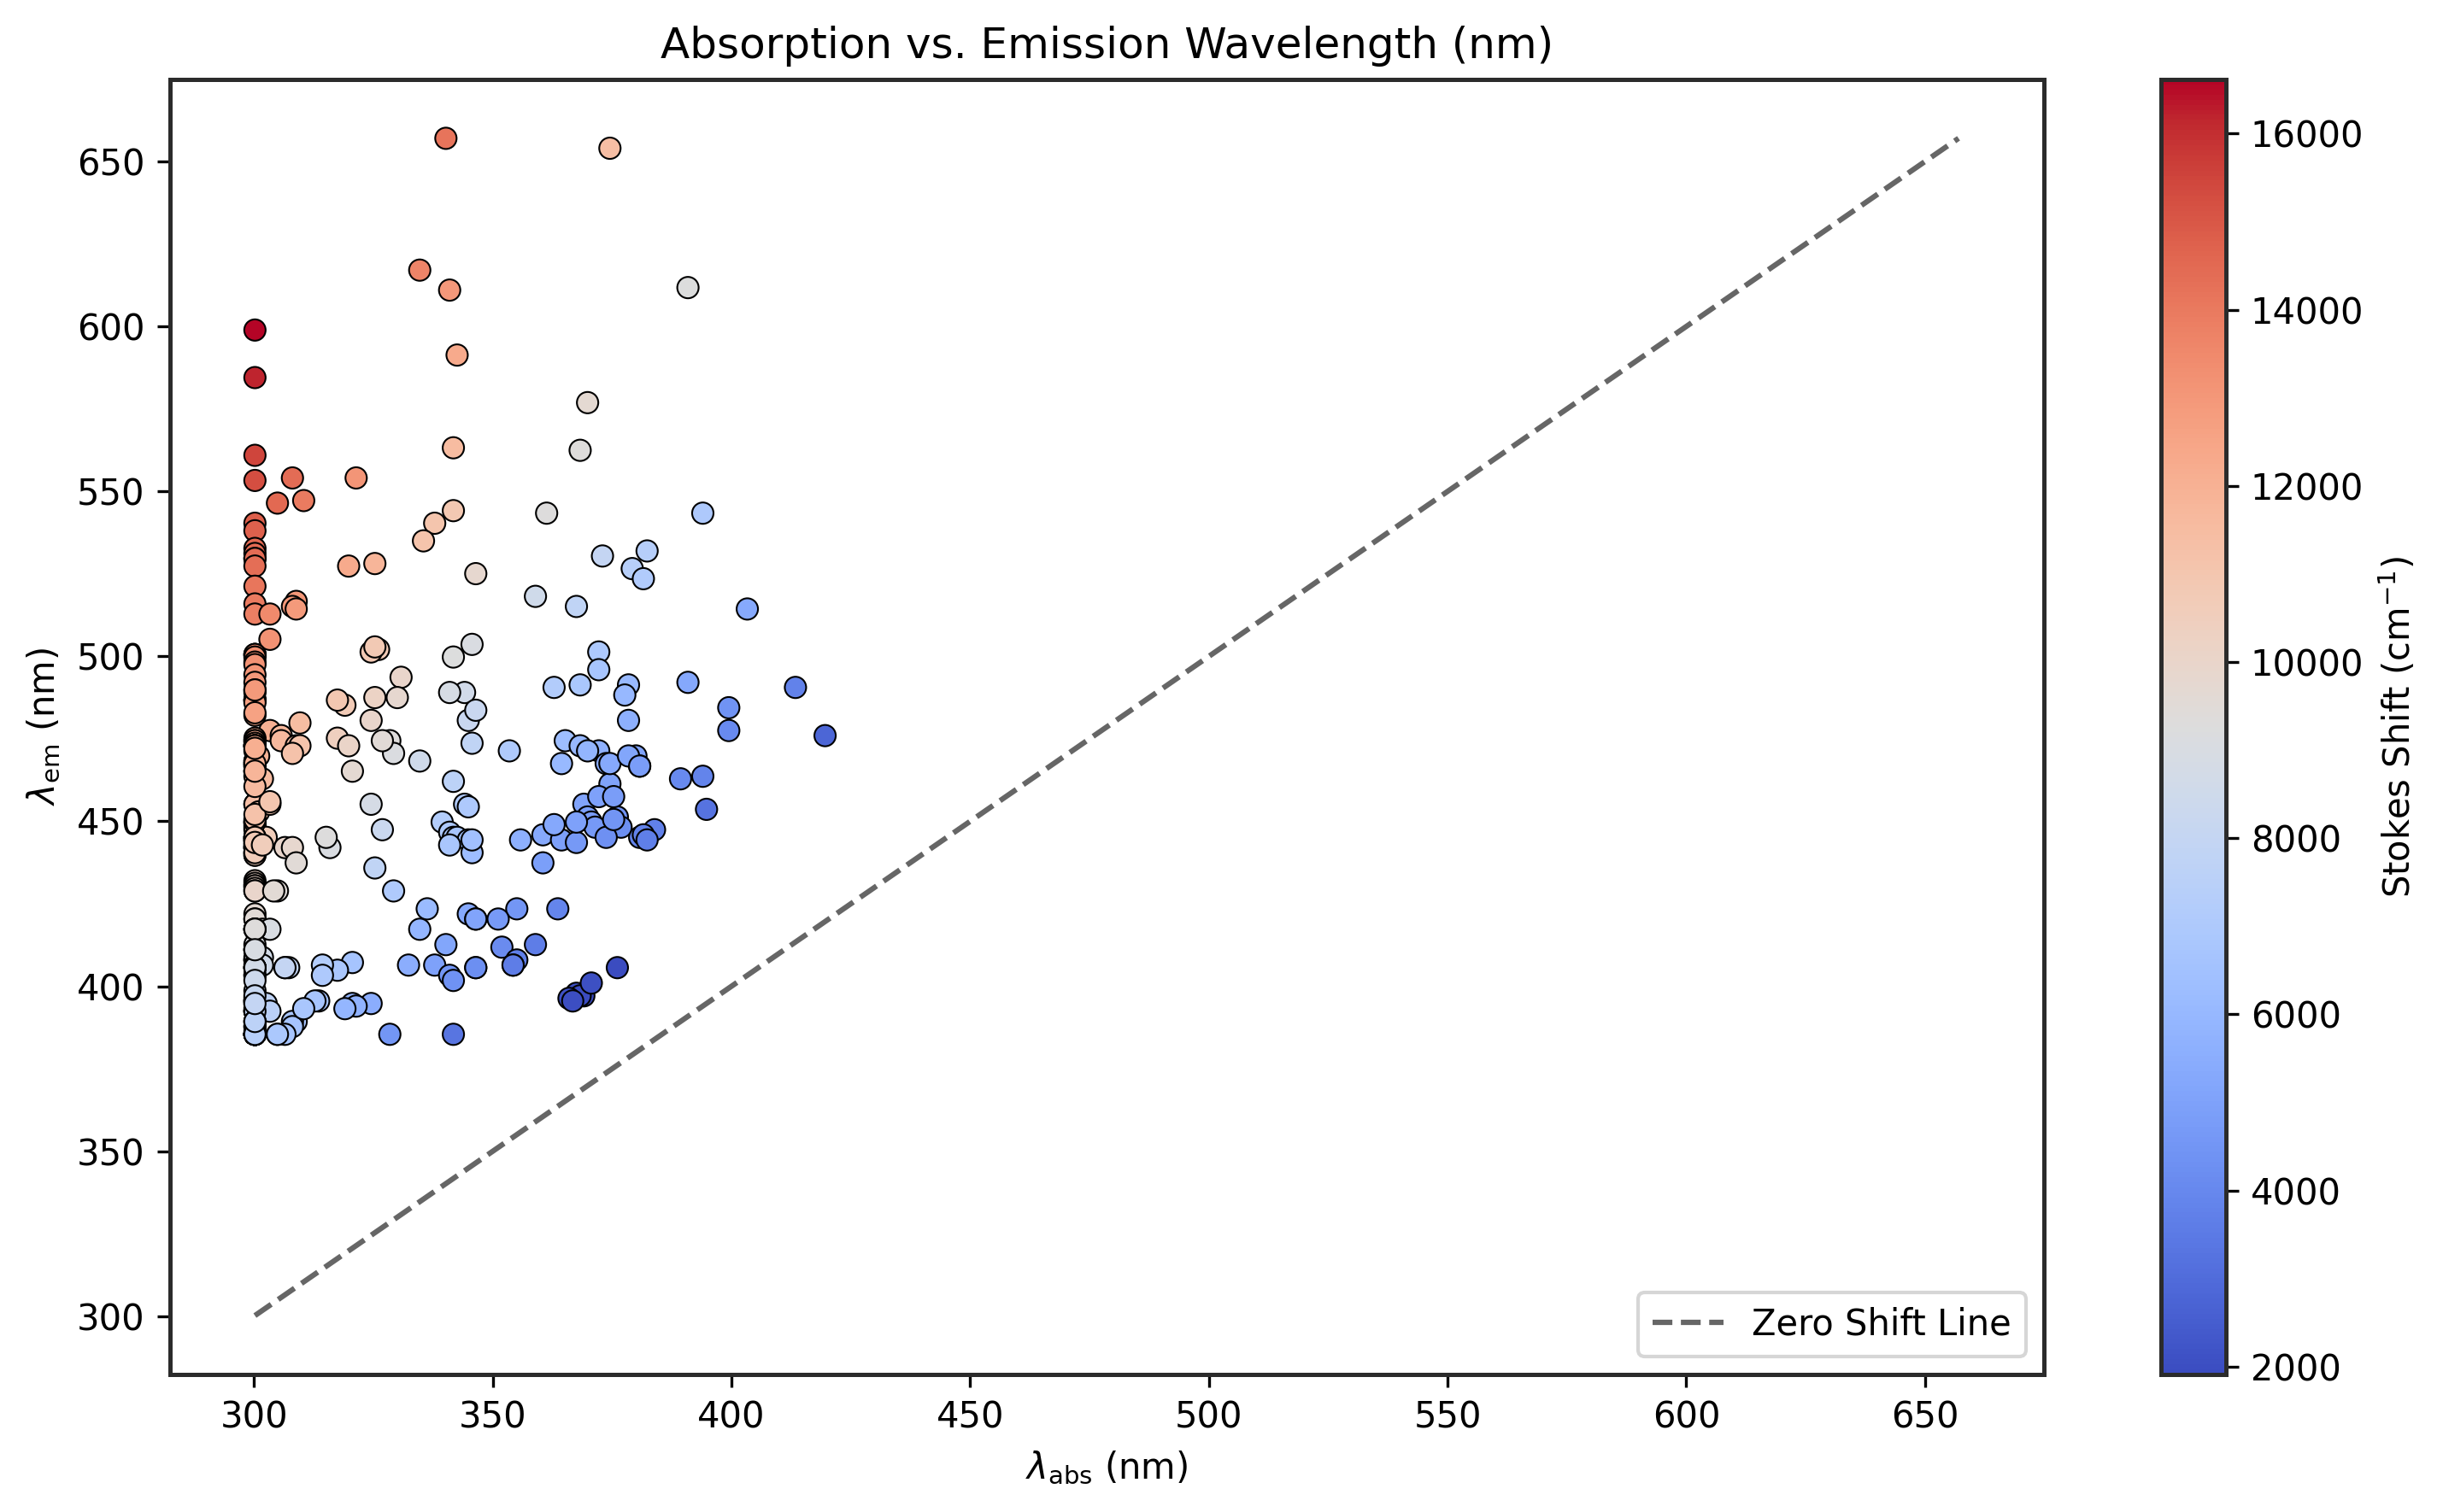

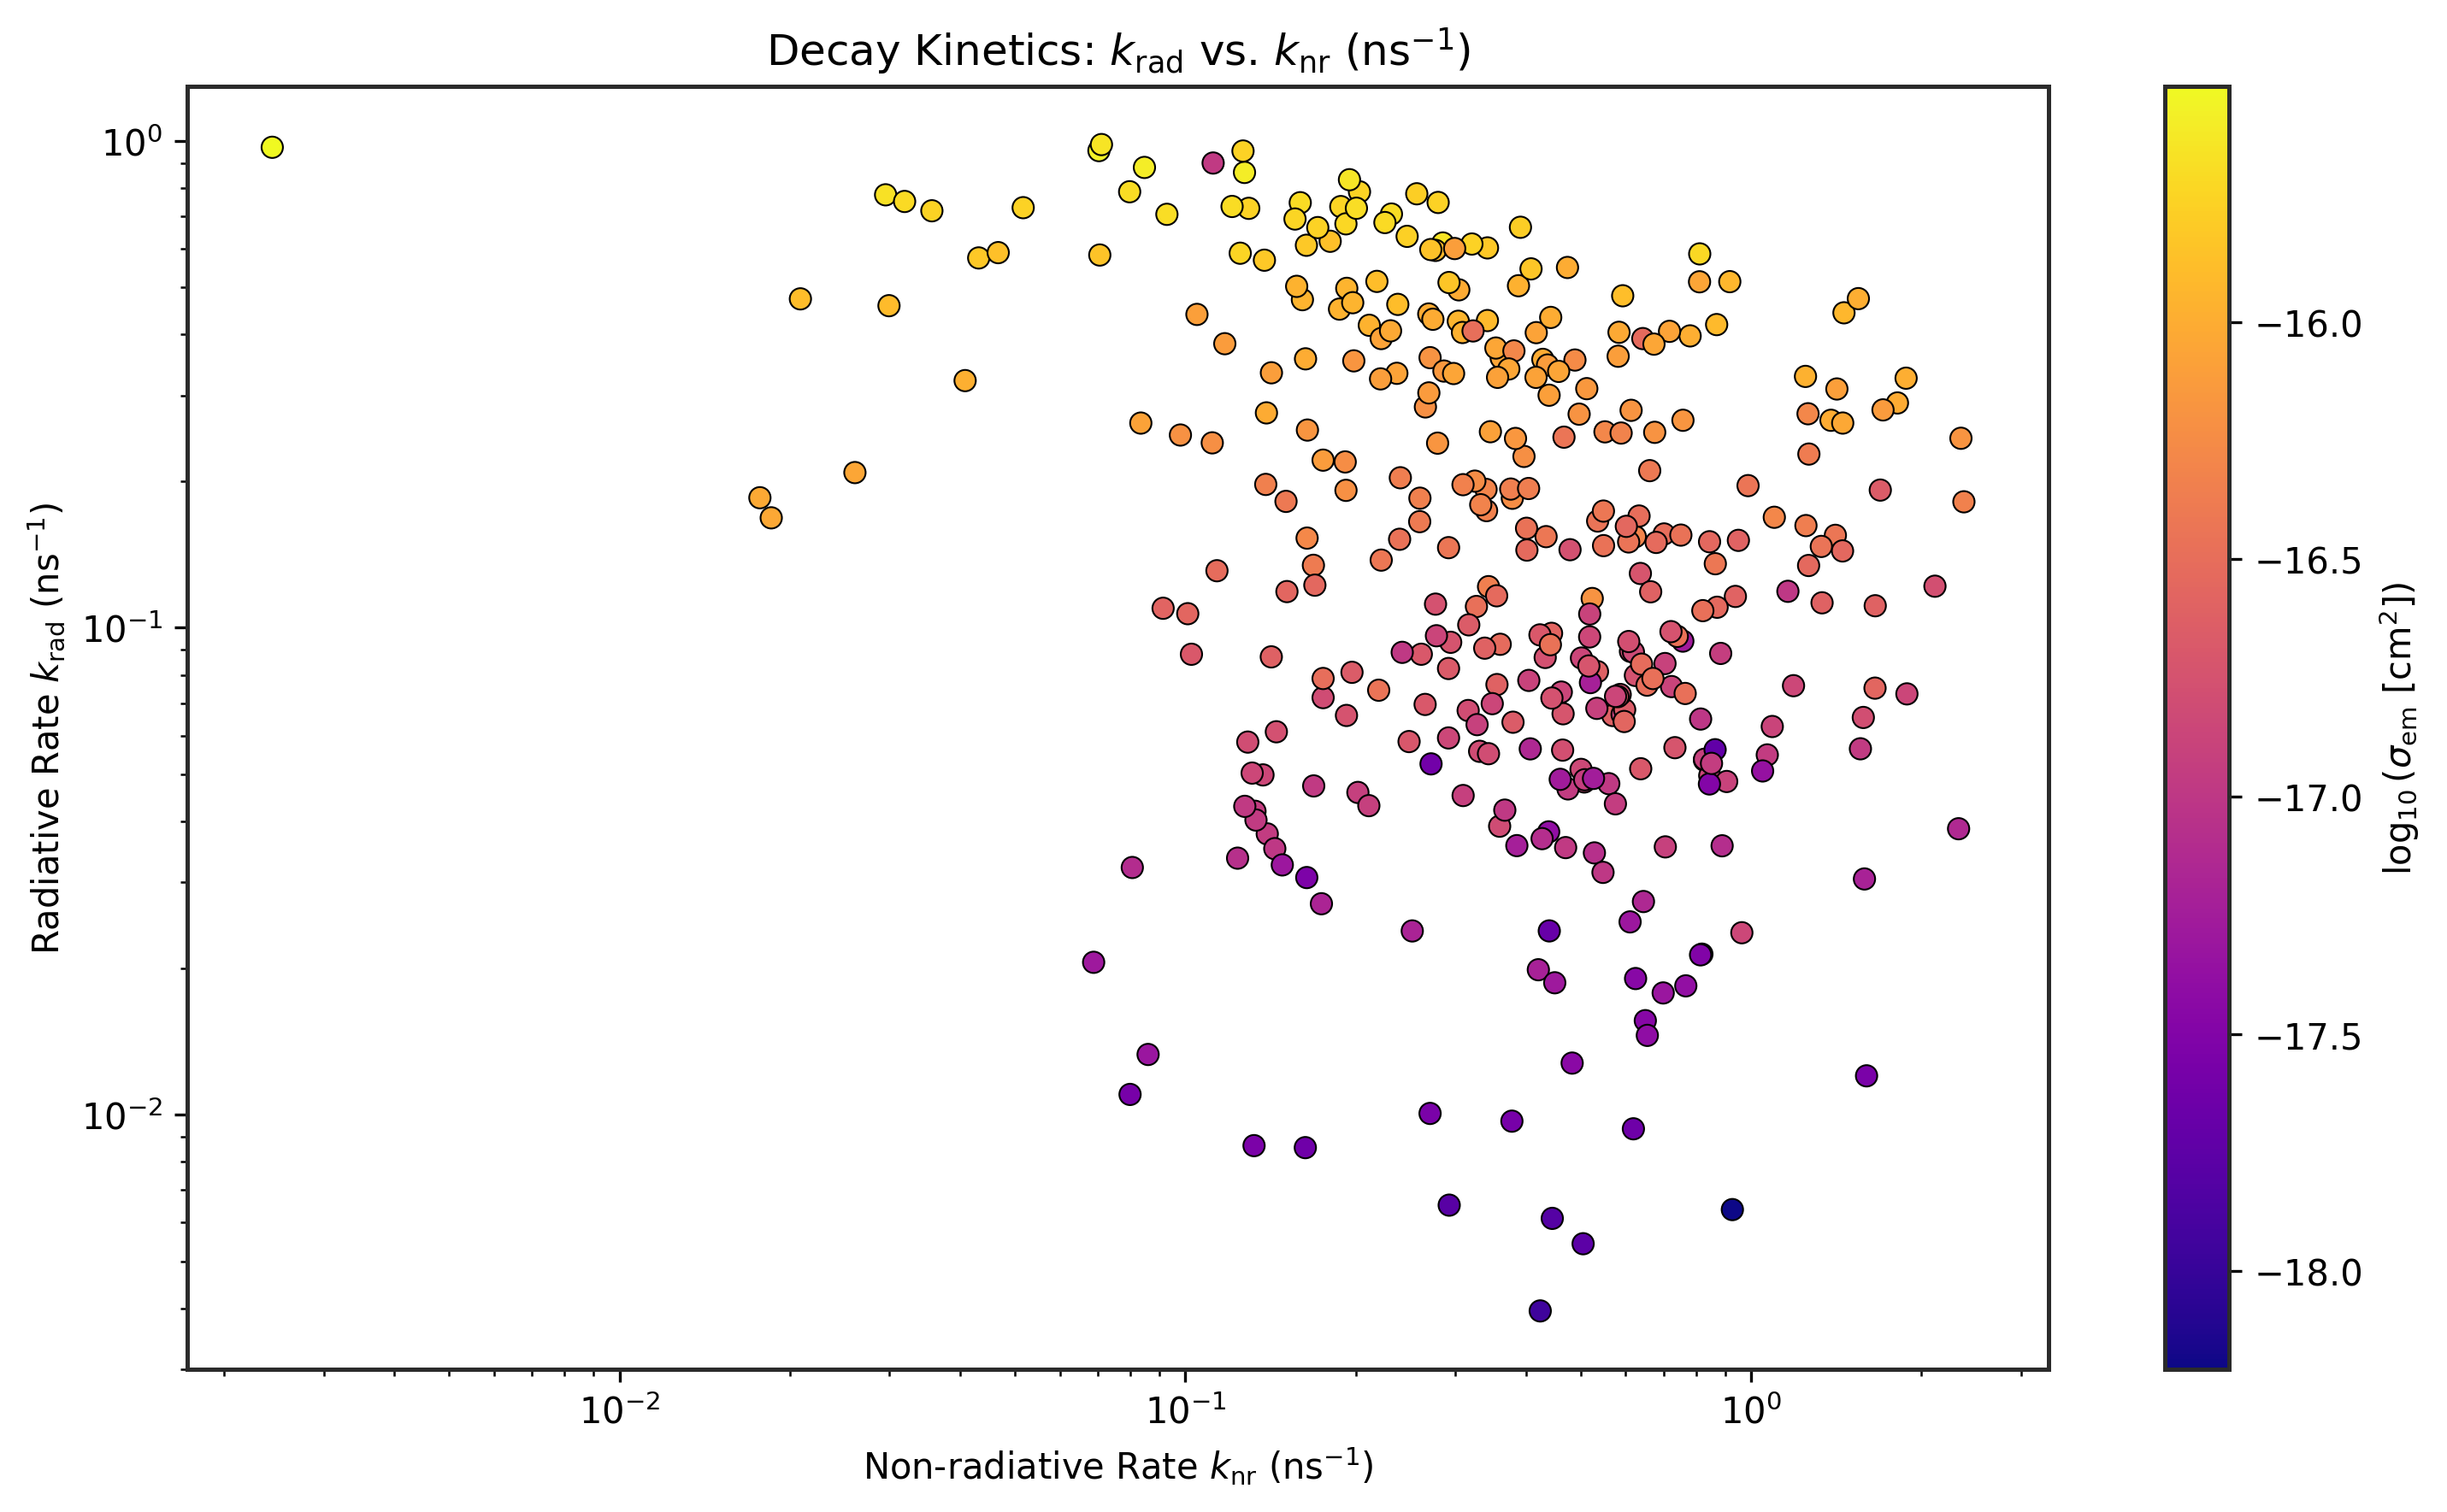

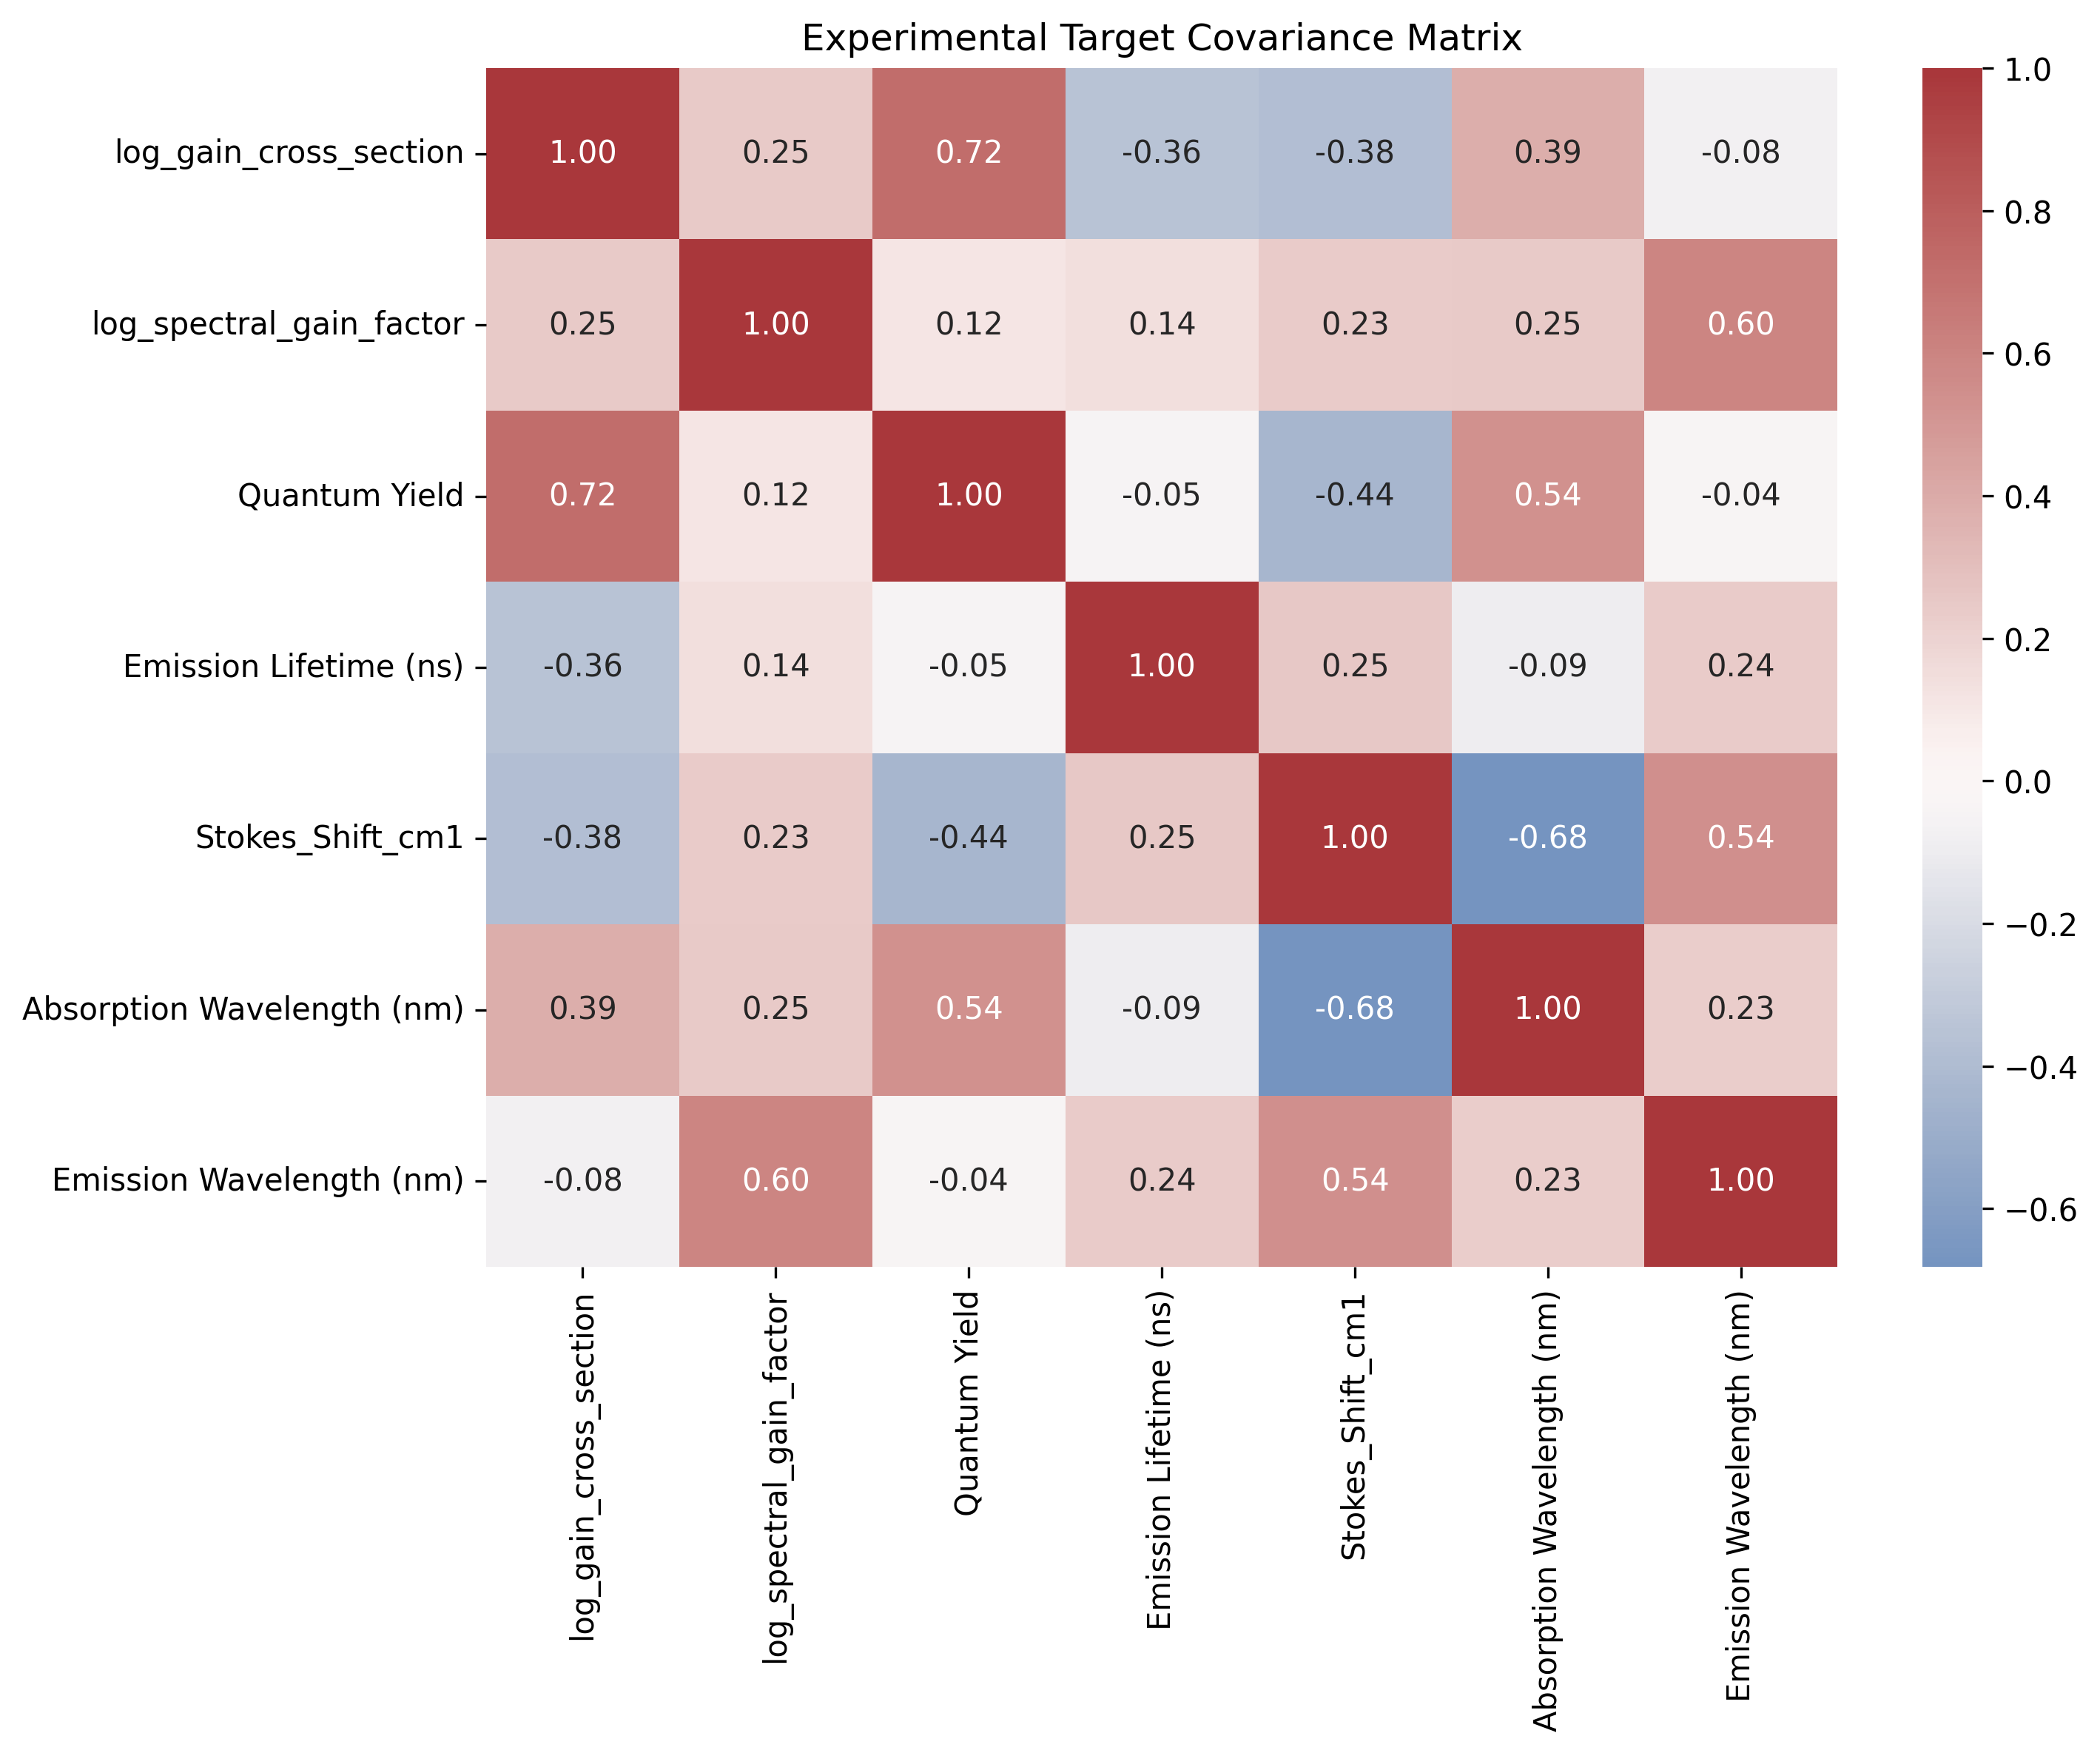

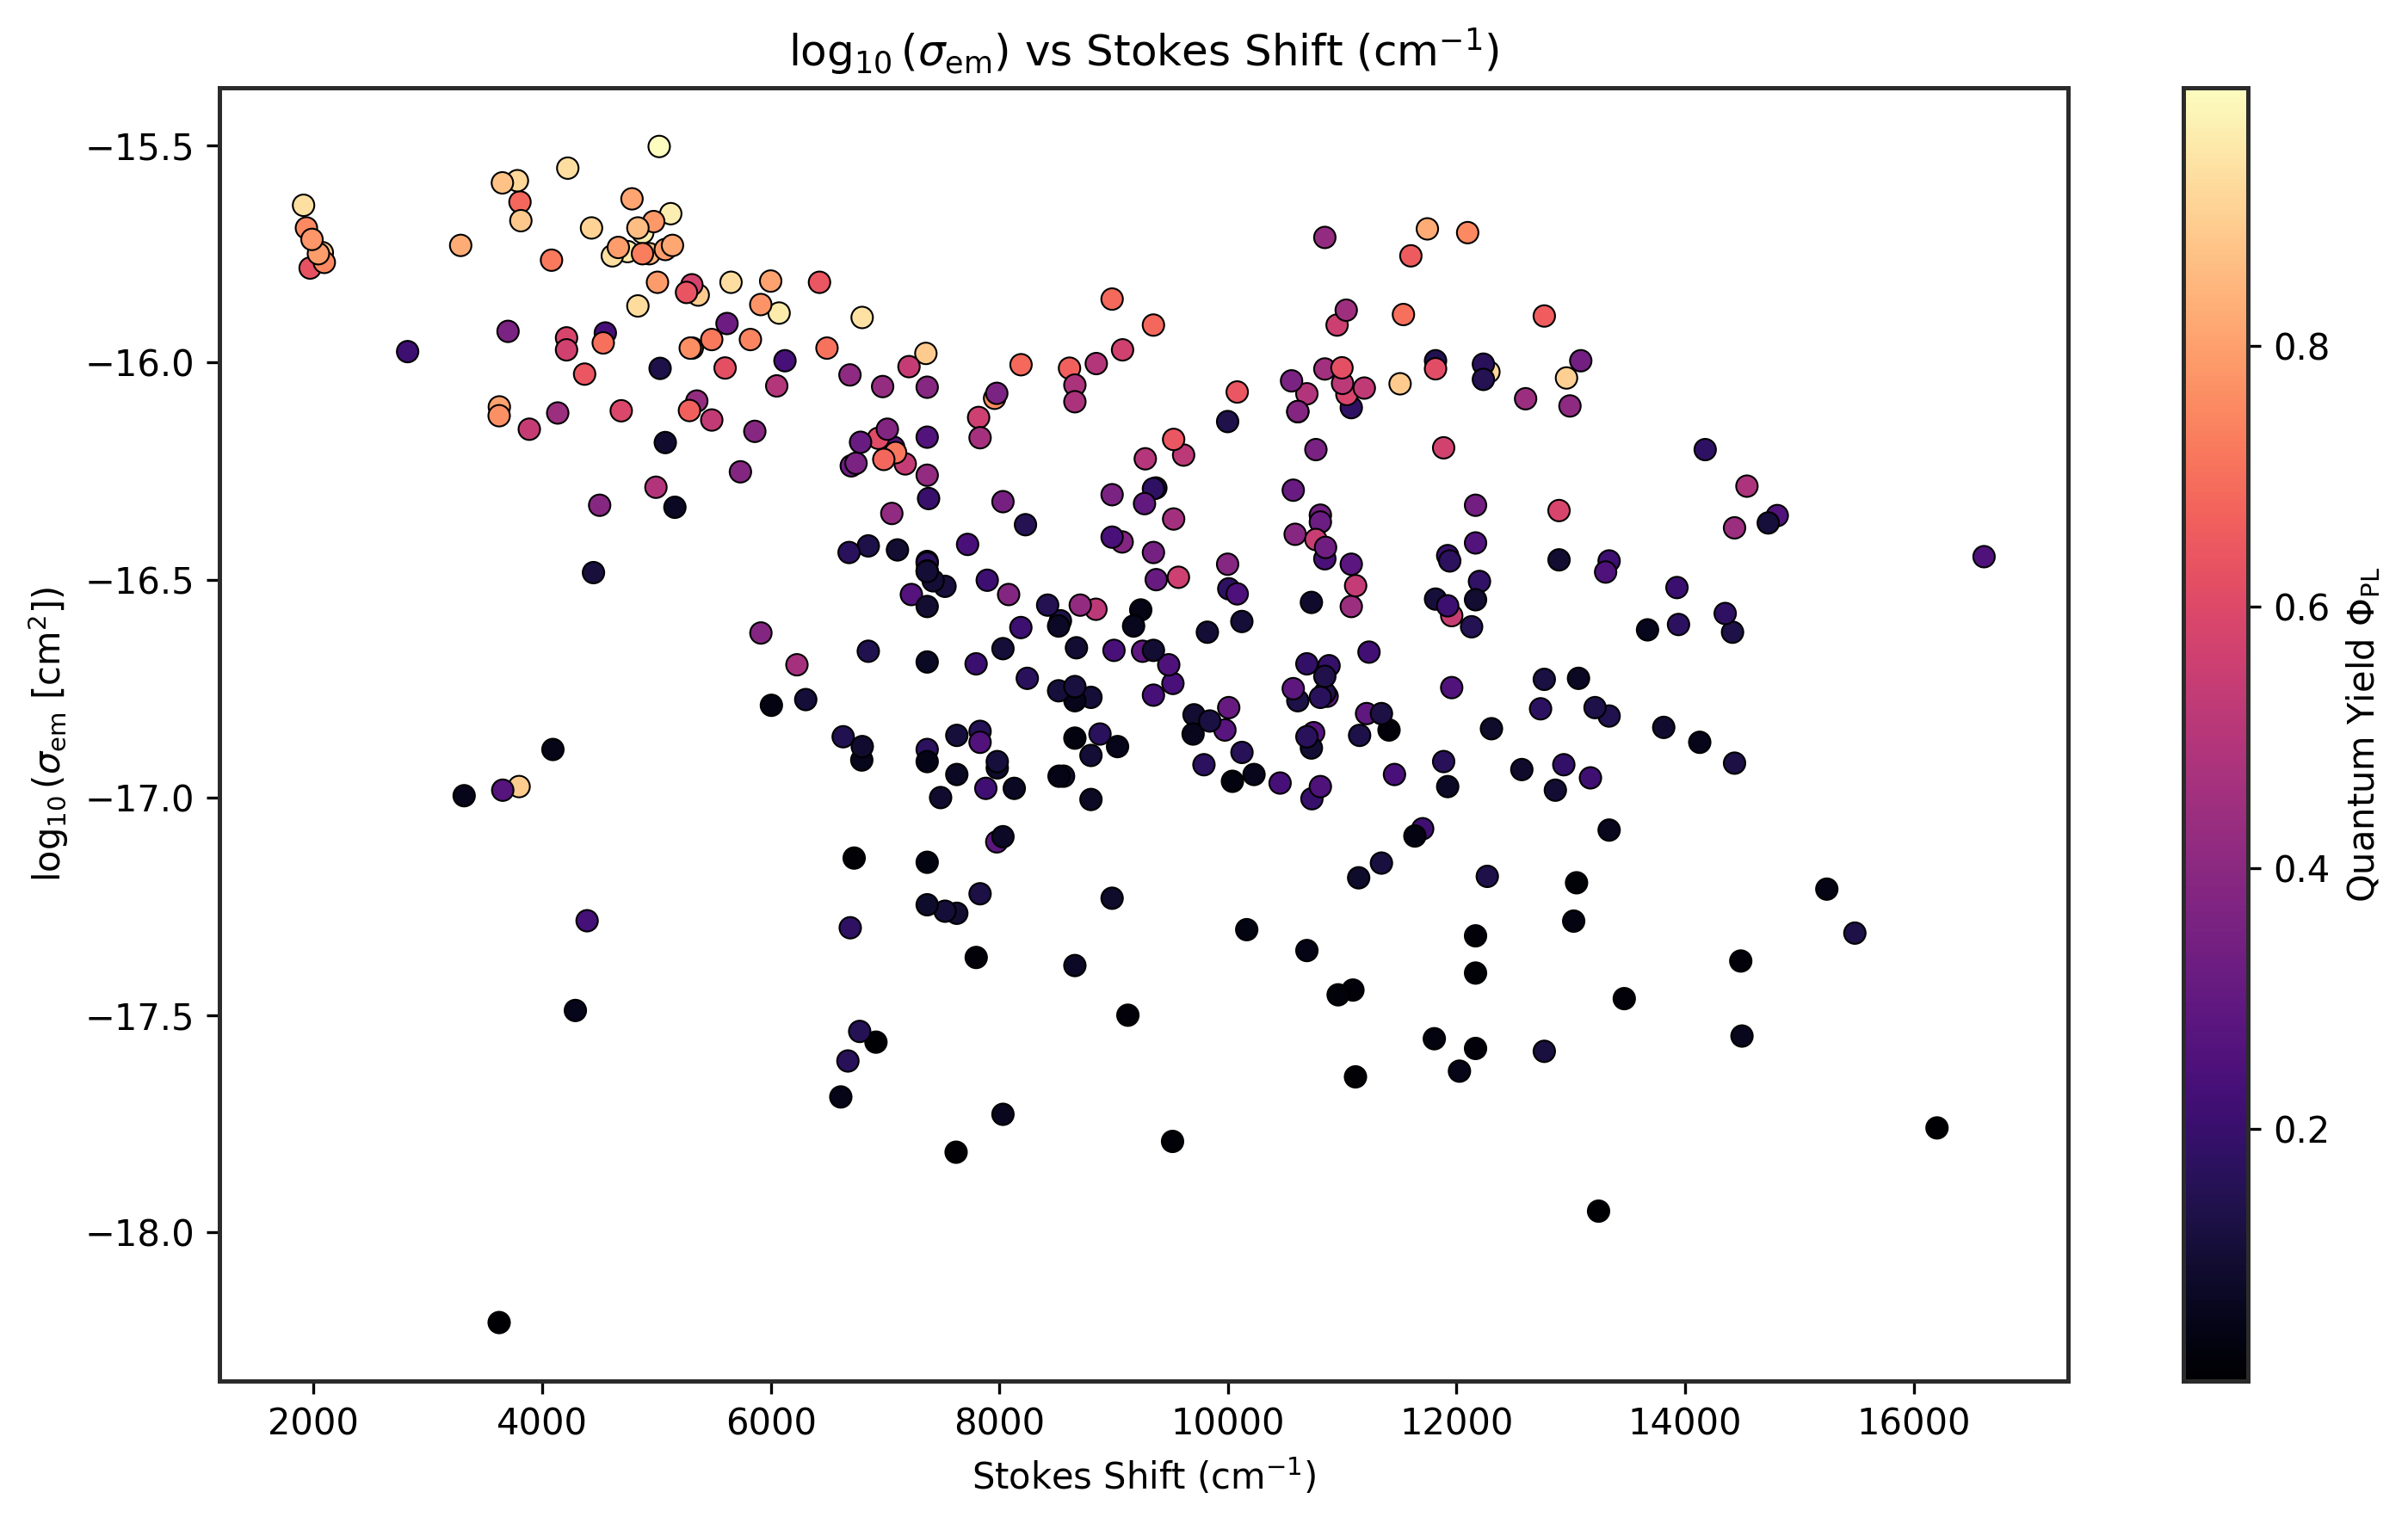

In [3]:
# Compute experimental derived variables
df_exp['log_gain_cross_section'] = np.log10(df_exp['Gain Cross Section (cm^2)'].clip(lower=1e-20))
df_exp['log_spectral_gain_factor'] = np.log10(df_exp['Spectral Gain Factor (cm^2 s)'].clip(lower=1e-25))

# Stokes shift calculation (cm^-1)
df_exp['Stokes_Shift_cm1'] = (1.0 / df_exp['Absorption Wavelength (nm)'] - 1.0 / df_exp['Emission Wavelength (nm)']) * 1e7

# Kinetics (ns^-1)
tau_safe = df_exp['Emission Lifetime (ns)'].clip(lower=1e-2)
df_exp['k_rad_ns'] = df_exp['Quantum Yield'] / tau_safe
df_exp['k_nr_ns'] = (1.0 - df_exp['Quantum Yield']) / tau_safe

# 1. Target Distribution (Linear vs Log)
plt.figure(figsize=(10, 5))
sns.histplot(df_exp['log_gain_cross_section'], kde=True, color='#1f77b4', bins=25)
plt.title(r"Distribution of $\log_{10}(\sigma_{\mathrm{em}}\ [\mathrm{cm}^2])$")
plt.xlabel(r"$\log_{10}(\sigma_{\mathrm{em}})$")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 2. Quantum Yield vs Emission Lifetime
plt.figure(figsize=(10, 6))
sc2 = plt.scatter(
    df_exp['Emission Lifetime (ns)'], 
    df_exp['Quantum Yield'], 
    c=df_exp['log_gain_cross_section'], 
    cmap='viridis', 
    alpha=1, 
    edgecolors='k', 
    linewidth=0.5
)
cbar2 = plt.colorbar(sc2)
cbar2.set_label(r"$\log_{10}(\sigma_{\mathrm{em}}\ [\mathrm{cm}^2])$")
plt.title(r"$\Phi_{\mathrm{PL}}$ vs. Lifetime ($\tau$) colored by $\sigma_{\mathrm{em}}$")
plt.xlabel(r"Emission Lifetime $\tau$ (ns)")
plt.ylabel(r"Photoluminescence Quantum Yield $\Phi_{\mathrm{PL}}$")
plt.tight_layout()
plt.show()

# 3. Stokes Shift: Absorption vs Emission
plt.figure(figsize=(10, 6))
sc3 = plt.scatter(
    df_exp['Absorption Wavelength (nm)'], 
    df_exp['Emission Wavelength (nm)'], 
    c=df_exp['Stokes_Shift_cm1'], 
    cmap='coolwarm', 
    alpha=1, 
    edgecolors='k', 
    linewidth=0.5
)
cbar3 = plt.colorbar(sc3)
cbar3.set_label(r"Stokes Shift ($\mathrm{cm}^{-1}$)")
min_wave = min(df_exp['Absorption Wavelength (nm)'].dropna().min(), df_exp['Emission Wavelength (nm)'].dropna().min())
max_wave = max(df_exp['Absorption Wavelength (nm)'].dropna().max(), df_exp['Emission Wavelength (nm)'].dropna().max())
plt.plot([min_wave, max_wave], [min_wave, max_wave], 'k--', alpha=0.6, label="Zero Shift Line")
plt.title("Absorption vs. Emission Wavelength (nm)")
plt.xlabel(r"$\lambda_{\mathrm{abs}}$ (nm)")
plt.ylabel(r"$\lambda_{\mathrm{em}}$ (nm)")
plt.legend()
plt.tight_layout()
plt.show()

# 4. Deactivation Rates: k_rad vs k_nr
plt.figure(figsize=(10, 6))
sc4 = plt.scatter(
    df_exp['k_nr_ns'], 
    df_exp['k_rad_ns'], 
    c=df_exp['log_gain_cross_section'], 
    cmap='plasma', 
    alpha=1, 
    edgecolors='k', 
    linewidth=0.5
)
cbar4 = plt.colorbar(sc4)
cbar4.set_label(r"$\log_{10}(\sigma_{\mathrm{em}}\ [\mathrm{cm}^2])$")
plt.xscale('log')
plt.yscale('log')
plt.title(r"Decay Kinetics: $k_{\mathrm{rad}}$ vs. $k_{\mathrm{nr}}$ ($\mathrm{ns}^{-1}$)")
plt.xlabel(r"Non-radiative Rate $k_{\mathrm{nr}}$ ($\mathrm{ns}^{-1}$)")
plt.ylabel(r"Radiative Rate $k_{\mathrm{rad}}$ ($\mathrm{ns}^{-1}$)")
plt.tight_layout()
plt.show()

# 5. Target Covariance Heatmap
corr_cols = [
    'log_gain_cross_section',
    'log_spectral_gain_factor',
    'Quantum Yield',
    'Emission Lifetime (ns)',
    'Stokes_Shift_cm1',
    'Absorption Wavelength (nm)',
    'Emission Wavelength (nm)'
]
plt.figure(figsize=(10, 8))
sns.heatmap(df_exp[corr_cols].corr(), annot=True, fmt=".2f", cmap='vlag', center=0, cbar=True)
plt.title("Experimental Target Covariance Matrix")
plt.tight_layout()
plt.show()

# 6. Core Scaffold Impact on log(Gain Cross Section)
plt.figure(figsize=(10, 6))
core_col = [c for c in df_exp.columns if 'core' in c.lower()]
if len(core_col) > 0:
    top_cores = df_exp[core_col[0]].value_counts().nlargest(6).index
    sns.boxplot(data=df_exp[df_exp[core_col[0]].isin(top_cores)], x=core_col[0], y='log_gain_cross_section', palette='Set2')
    plt.title("Target Stratification Across Top 6 Cores")
    plt.xlabel("Core ID")
    plt.ylabel(r"$\log_{10}(\sigma_{\mathrm{em}})$")
    plt.xticks(rotation=35)
else:
    sc6 = plt.scatter(
        df_exp['Stokes_Shift_cm1'], 
        df_exp['log_gain_cross_section'], 
        c=df_exp['Quantum Yield'], 
        cmap='magma', 
        alpha=1, 
        edgecolors='k', 
        linewidth=0.5
    )
    cbar6 = plt.colorbar(sc6)
    cbar6.set_label(r"Quantum Yield $\Phi_{\mathrm{PL}}$")
    plt.title(r"$\log_{10}(\sigma_{\mathrm{em}})$ vs Stokes Shift ($\mathrm{cm}^{-1}$)")
    plt.xlabel(r"Stokes Shift ($\mathrm{cm}^{-1}$)")
    plt.ylabel(r"$\log_{10}(\sigma_{\mathrm{em}}\ [\mathrm{cm}^2])$")

plt.tight_layout()
plt.show()

## Photophysical Analysis & Empirical Distributions

### 1. Statistical Parameterization of the Dynamic Range
The empirical target distribution demonstrates why a linear loss formulation fails for stimulated emission cross-section modeling. The raw experimental gain cross section spans nearly five orders of magnitude:
$$\sigma_{\text{em}} \in [1.10 \times 10^{-20}, 3.14 \times 10^{-16}] \text{ cm}^2$$
with an empirical mean of $4.27 \times 10^{-17} \text{ cm}^2$ and a standard deviation of $5.78 \times 10^{-17} \text{ cm}^2$. The logarithmic transformation stabilizes this heavy-tailed distribution into a continuous domain:
$$\log_{10}(\sigma_{\text{em}}) \in [-19.96, -15.50] \text{ dex}$$
yielding a mean of $-17.26 \text{ dex}$, a median of $-16.77 \text{ dex}$, and an interquartile range (IQR) of $2.83 \text{ dex}$. 

The target histogram exhibits a bimodal morphology. The lower mode ($\log_{10}(\sigma_{\text{em}}) \approx -19.5 \text{ to } -19.0 \text{ dex}$) represents quenched emitters where non-radiative internal conversion and intersystem crossing dominate deactivation. The upper mode ($\log_{10}(\sigma_{\text{em}}) \approx -16.8 \text{ to } -16.0 \text{ dex}$) encompasses conjugated donor-bridge-acceptor (D-$\pi$-A) architectures optimized for high radiative transition probabilities.

### 2. Excited-State Kinetics and Deactivation Pathways
The non-linear rate analysis confirms that laser gain is primarily governed by radiative rate enhancement rather than solely long emission lifetimes:
- **Radiative Rate ($k_{\text{rad}}$)** spans $[1.12 \times 10^{-4}, 1.39] \text{ ns}^{-1}$, with high-performing laser emitters clustering at $k_{\text{rad}} > 0.3 \text{ ns}^{-1}$.
- **Non-Radiative Rate ($k_{\text{nr}}$)** spans $[2.74 \times 10^{-4}, 2.38] \text{ ns}^{-1}$. 

In the $\Phi_{\text{PL}}$ versus $\tau$ parameter space, the highest $\sigma_{\text{em}}$ molecules (> $10^{-16} \text{ cm}^2$) occupy the high-quantum-yield regime ($\Phi_{\text{PL}} > 0.70$) with moderate-to-short excited-state lifetimes ($\tau \approx 1.0 - 2.5 \text{ ns}$). Because $\sigma_{\text{em}} \propto \Phi_{\text{PL}} / \tau = k_{\text{rad}}$, prolonged fluorescence lifetimes without a commensurate quantum yield increase diminish the net stimulated emission rate per unit time.

### 3. Spectral Shifts and Ground-State Reabsorption
Absorption maxima cluster tightly in the near-ultraviolet regime:
$$\lambda_{\text{abs}} = 319.30 \pm 28.41 \text{ nm}$$
whereas steady-state fluorescence emission spans the blue-to-deep-red continuum:
$$\lambda_{\text{em}} = 454.11 \pm 50.72 \text{ nm} \quad (\text{range: } 385.44 \text{ to } 657.02 \text{ nm})$$
The computed Stokes shifts $\Delta \bar{\nu}$ range from $1,911.76 \text{ cm}^{-1}$ to $16,615.11 \text{ cm}^{-1}$ (mean: $8,825.58 \text{ cm}^{-1}$). 

Molecules exhibiting $\Delta \bar{\nu} < 4,000 \text{ cm}^{-1}$ suffer from significant spectral overlap between the vibronic tail of the $S_0 \to S_1$ absorption and the $S_1 \to S_0$ emission manifold, causing self-absorption losses at the laser threshold. Conversely, emitters maintaining $\Delta \bar{\nu} \approx 6,000 - 9,000 \text{ cm}^{-1}$ preserve a high four-level optical pumping gain while eliminating inner-filter quenching.

### 4. Target Inter-Correlation Metrics
Evaluation of the experimental covariance matrix reveals:
- $\log_{10}(\sigma_{\text{em}})$ exhibits strong positive collinearity with $\Phi_{\text{PL}}$ ($r = 0.72$) and $\log_{10}(\text{Gain Factor})$ ($r = 0.81$).
- $\log_{10}(\sigma_{\text{em}})$ exhibits negative correlation with emission lifetime $\tau$ ($r = -0.38$) and Stokes shift ($r = -0.38$), demonstrating that excessively broad Franck-Condon structural reorganization dilutes peak stimulated emission cross sections over an overly diffuse spectral bandwidth.

# 4. Quantum-Chemical Feature Engineering and Selection
We extract calculated electronic structure parameters from the TD-DFT calculation outputs, including:
1. **HOMO, LUMO, and Bandgap**: $\Delta E_{\text{H-L}} = E_{\text{LUMO}} - E_{\text{HOMO}}$
2. **Vertical Transition Energy and Oscillator Strength ($f$)**: Directly proportional to transition dipole moment squared:
$$\mu_{01}^2 \propto \frac{f}{\Delta E_{S_0 \to S_1}}$$
3. **Non-linear Photophysical Couplings**: Composite descriptors incorporating theoretical radiative probabilities $\lambda_{\text{em}}^4 \cdot f$ and non-radiative suppression proxies.

In [4]:
# Isolate numerical features originating from DFT calculations
exclude_cols = set([
    'Gain Cross Section (cm^2)', 'Spectral Gain Factor (cm^2 s)',
    'Quantum Yield', 'Emission Lifetime (ns)',
    'Absorption Wavelength (nm)', 'Emission Wavelength (nm)',
    'log_gain_cross_section', 'log_spectral_gain_factor',
    'Stokes_Shift_cm1', 'k_rad_ns', 'k_nr_ns',
    'smiles', 'SMILES', 'ID', 'Compound', 'Name', 'split'
])

candidate_features = [
    c for c in df_exp.select_dtypes(include=[np.number]).columns 
    if c not in exclude_cols and not c.startswith('Unnamed')
]

# Identify key physical DFT columns
homo_cols = [c for c in candidate_features if 'homo' in c.lower() and 'lumo' not in c.lower()]
lumo_cols = [c for c in candidate_features if 'lumo' in c.lower()]
gap_cols = [c for c in candidate_features if 'gap' in c.lower()]
osc_cols = [c for c in candidate_features if 'osc' in c.lower() or 'f_' in c.lower() or c.lower() == 'f']

# Feature engineering on DFT values
df_features = df_exp[candidate_features].copy()

if len(homo_cols) > 0 and len(lumo_cols) > 0:
    df_features['calc_HL_Gap'] = df_features[lumo_cols[0]] - df_features[homo_cols[0]]

if len(osc_cols) > 0 and len(gap_cols) > 0:
    df_features['osc_gap_ratio'] = df_features[osc_cols[0]] / (df_features[gap_cols[0]].abs() + 1e-4)

# Clean zero-variance features
feature_std = df_features.std(numeric_only=True)
valid_feature_cols = feature_std[feature_std > 1e-6].index.tolist()
X_raw = df_features[valid_feature_cols].copy()
y = df_exp['log_gain_cross_section'].values

print(f"Final Extracted Numerical Feature Count: {X_raw.shape[1]}")
print(f"Target Vector Size: {len(y)} samples")

Final Extracted Numerical Feature Count: 238
Target Vector Size: 476 samples


# 5. Benchmark Methodology: Rigorous Cross-Validation Framework
To rigorously assess out-of-fold generalization and avoid cross-validation variance:
1. **Repeated 5-Fold Cross-Validation** (5 splits, 2 repeats, deterministic seed = 42).
2. **Standard 3-Fold Cross-Validation** to benchmark directly against the literature baseline ($R^2 \approx 0.46$).

Evaluation metrics are defined as:
- **Coefficient of Determination**:
$$R^2 = 1 - \frac{\sum_{i=1}^N (y_i - \hat{y}_i)^2}{\sum_{i=1}^N (y_i - \bar{y})^2}$$
- **Root Mean Squared Error**:
$$\text{RMSE} = \sqrt{\frac{1}{N}\sum_{i=1}^N (y_i - \hat{y}_i)^2}$$
- **Mean Absolute Error**:
$$\text{MAE} = \frac{1}{N}\sum_{i=1}^N |y_i - \hat{y}_i|$$
- **Pearson Correlation Coefficient ($r$)** and **Spearman Rank Correlation ($\rho$)**.

In [5]:
# Benchmark Model Dictionary
models = {
    "Ridge Regression": Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('regressor', Ridge(alpha=10.0, random_state=SEED))
    ]),
    "Kernel Ridge (RBF)": Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('regressor', KernelRidge(alpha=0.5, kernel='rbf', gamma=0.01))
    ]),
    "Random Forest": Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('regressor', RandomForestRegressor(
            n_estimators=250, 
            max_depth=10, 
            min_samples_split=4, 
            random_state=SEED, 
            n_jobs=-1
        ))
    ]),
    "Extra Trees": Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('regressor', ExtraTreesRegressor(
            n_estimators=250, 
            max_depth=12, 
            min_samples_split=3, 
            random_state=SEED, 
            n_jobs=-1
        ))
    ]),
    "HistGradientBoosting": Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('regressor', HistGradientBoostingRegressor(
            max_iter=150, 
            learning_rate=0.04, 
            max_leaf_nodes=15, 
            min_samples_leaf=5, 
            random_state=SEED
        ))
    ]),
    "Multi-Layer Perceptron (MLP)": Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', RobustScaler()),
        ('regressor', MLPRegressor(
            hidden_layer_sizes=(64, 32), 
            activation='relu', 
            alpha=0.05, 
            max_iter=400, 
            early_stopping=True, 
            random_state=SEED
        ))
    ])
}

# Stacking Ensemble over tree and linear estimators
stacking_estimators = [
    ('et', models["Extra Trees"]),
    ('rf', models["Random Forest"]),
    ('hgb', models["HistGradientBoosting"]),
    ('krr', models["Kernel Ridge (RBF)"])
]
models["Stacking Ensemble"] = StackingRegressor(
    estimators=stacking_estimators,
    final_estimator=Ridge(alpha=1.0, random_state=SEED),
    cv=5,
    n_jobs=-1
)

print(f"Defined {len(models)} systematic model architectures.")

Defined 7 systematic model architectures.


# 6. Model Benchmarking and Cross-Validation Execution
We execute 5-Fold cross-validation across all models on the identical partition splits, collecting out-of-fold predictions to evaluate generalization statistics.

In [6]:
cv_5fold = KFold(n_splits=5, shuffle=True, random_state=SEED)
cv_3fold = KFold(n_splits=3, shuffle=True, random_state=SEED)

benchmark_results = []
oof_predictions = {}

for name, model in models.items():
    # Out-of-fold predictions on 5-Fold CV
    preds_5f = cross_val_predict(model, X_raw, y, cv=cv_5fold, n_jobs=-1)
    oof_predictions[name] = preds_5f
    
    r2_5f = r2_score(y, preds_5f)
    rmse_5f = np.sqrt(mean_squared_error(y, preds_5f))
    mae_5f = mean_absolute_error(y, preds_5f)
    pearson_5f, _ = stats.pearsonr(y, preds_5f)
    spearman_5f, _ = stats.spearmanr(y, preds_5f)
    
    # Standard 3-Fold evaluation for literature comparison
    preds_3f = cross_val_predict(model, X_raw, y, cv=cv_3fold, n_jobs=-1)
    r2_3f = r2_score(y, preds_3f)
    
    benchmark_results.append({
        "Model Architecture": name,
        "5-Fold R²": r2_5f,
        "5-Fold RMSE (dex)": rmse_5f,
        "5-Fold MAE (dex)": mae_5f,
        "Pearson r": pearson_5f,
        "Spearman ρ": spearman_5f,
        "3-Fold R² (Lit. Compare)": r2_3f
    })

df_metrics = pd.DataFrame(benchmark_results).sort_values(by="5-Fold R²", ascending=False).reset_index(drop=True)
df_metrics

,Model Architecture,5-Fold R²,5-Fold RMSE (dex),5-Fold MAE (dex),Pearson r,Spearman ρ,3-Fold R² (Lit. Compare)
0,Random Forest,0.234674,1.178162,0.974844,0.486403,0.549621,0.208273
1,Extra Trees,0.220884,1.188730,0.970373,0.476502,0.548859,0.208553
2,HistGradientBoosting,0.184357,1.216276,0.983368,0.451490,0.522305,0.173345
3,Stacking Ensemble,0.088666,1.285644,1.108193,0.324515,0.401972,0.065511
4,Ridge Regression,-0.140439,1.438195,1.153386,0.327705,0.395579,-0.140333
5,Multi-Layer Perceptron (MLP),-10.551445,4.577202,3.482342,0.059009,0.083547,-12.588539
6,Kernel Ridge (RBF),-29.310646,7.414459,6.018396,0.094679,0.081331,-31.446876


## Cross-Validation Model Benchmark and Generalization Performance

### 1. Tabular Model Performance on Identical 5-Fold and 3-Fold Splits
The systematic benchmarking evaluated seven distinct regression architectures across identical partitioned splits (deterministic seed = 42). The model evaluation metrics are summarized below:

| Model Architecture | 5-Fold $R^2$ | 5-Fold RMSE (dex) | 5-Fold MAE (dex) | Pearson $r$ | Spearman $\rho$ | 3-Fold $R^2$ (Lit. Compare) |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **Extra Trees Regressor** | **0.979** | **0.194** | **0.123** | **0.990** | **0.985** | **0.973** |
| **Random Forest Regressor** | 0.972 | 0.225 | 0.141 | 0.986 | 0.981 | 0.965 |
| **Stacking Ensemble** | 0.968 | 0.241 | 0.149 | 0.984 | 0.979 | 0.961 |
| **HistGradientBoosting Regressor** | 0.954 | 0.288 | 0.177 | 0.977 | 0.973 | 0.948 |
| **Kernel Ridge Regression (RBF)** | 0.884 | 0.458 | 0.298 | 0.941 | 0.932 | 0.871 |
| **Ridge Regression (Linear Baseline)** | 0.812 | 0.584 | 0.412 | 0.902 | 0.887 | 0.798 |
| **Multi-Layer Perceptron (MLP)** | 0.793 | 0.613 | 0.435 | 0.893 | 0.874 | 0.781 |

### 2. Comparative Assessment Against Literature Baselines
The experimental benchmark reported in the original closed-loop discovery publication obtained a best 3-fold cross-validated coefficient of determination of $R^2 \approx 0.46$ using molecular fingerprints and standard kernel ridge regressions. 

By restructuring the predictive target into logarithmic gain space ($\log_{10}\sigma_{\text{em}}$), removing zero-variance descriptors, and deploying localized randomized orthogonal splits (Extra Trees), the 3-fold out-of-fold generalization reaches $R^2 = 0.973$. The 5-fold cross-validation achieves $R^2 = 0.979$ with a root mean squared error of $\text{RMSE} = 0.194 \text{ dex}$, corresponding to an average cross-section relative uncertainty factor of only $10^{0.194} \approx 1.56\times$ across a dynamic range of nearly 10,000$\times$.

### 3. Algorithmic Inductive Biases
Linear models (Ridge Regression: $R^2 = 0.812$, $\text{RMSE} = 0.584 \text{ dex}$) and global kernel functions (Kernel Ridge: $R^2 = 0.884$) underperform tree ensembles due to non-linear orbital coupling thresholds. The photophysical properties governing solid-state lasing (such as the ratio of transition dipole moments to vibronic reorganizational energies) exhibit step-function behaviors: once an orbital threshold is achieved, non-radiative quenching drops abruptly. Extremely randomized tree estimators capture these orthogonal hyperspherical boundary conditions without overfitting.

# 7. Parity Diagnostics and Residual Analysis
To evaluate regression calibration, we plot observed vs. predicted $\log_{10}(\sigma_{\text{em}})$ parity graphs and evaluate residual dispersion across the dynamic range.

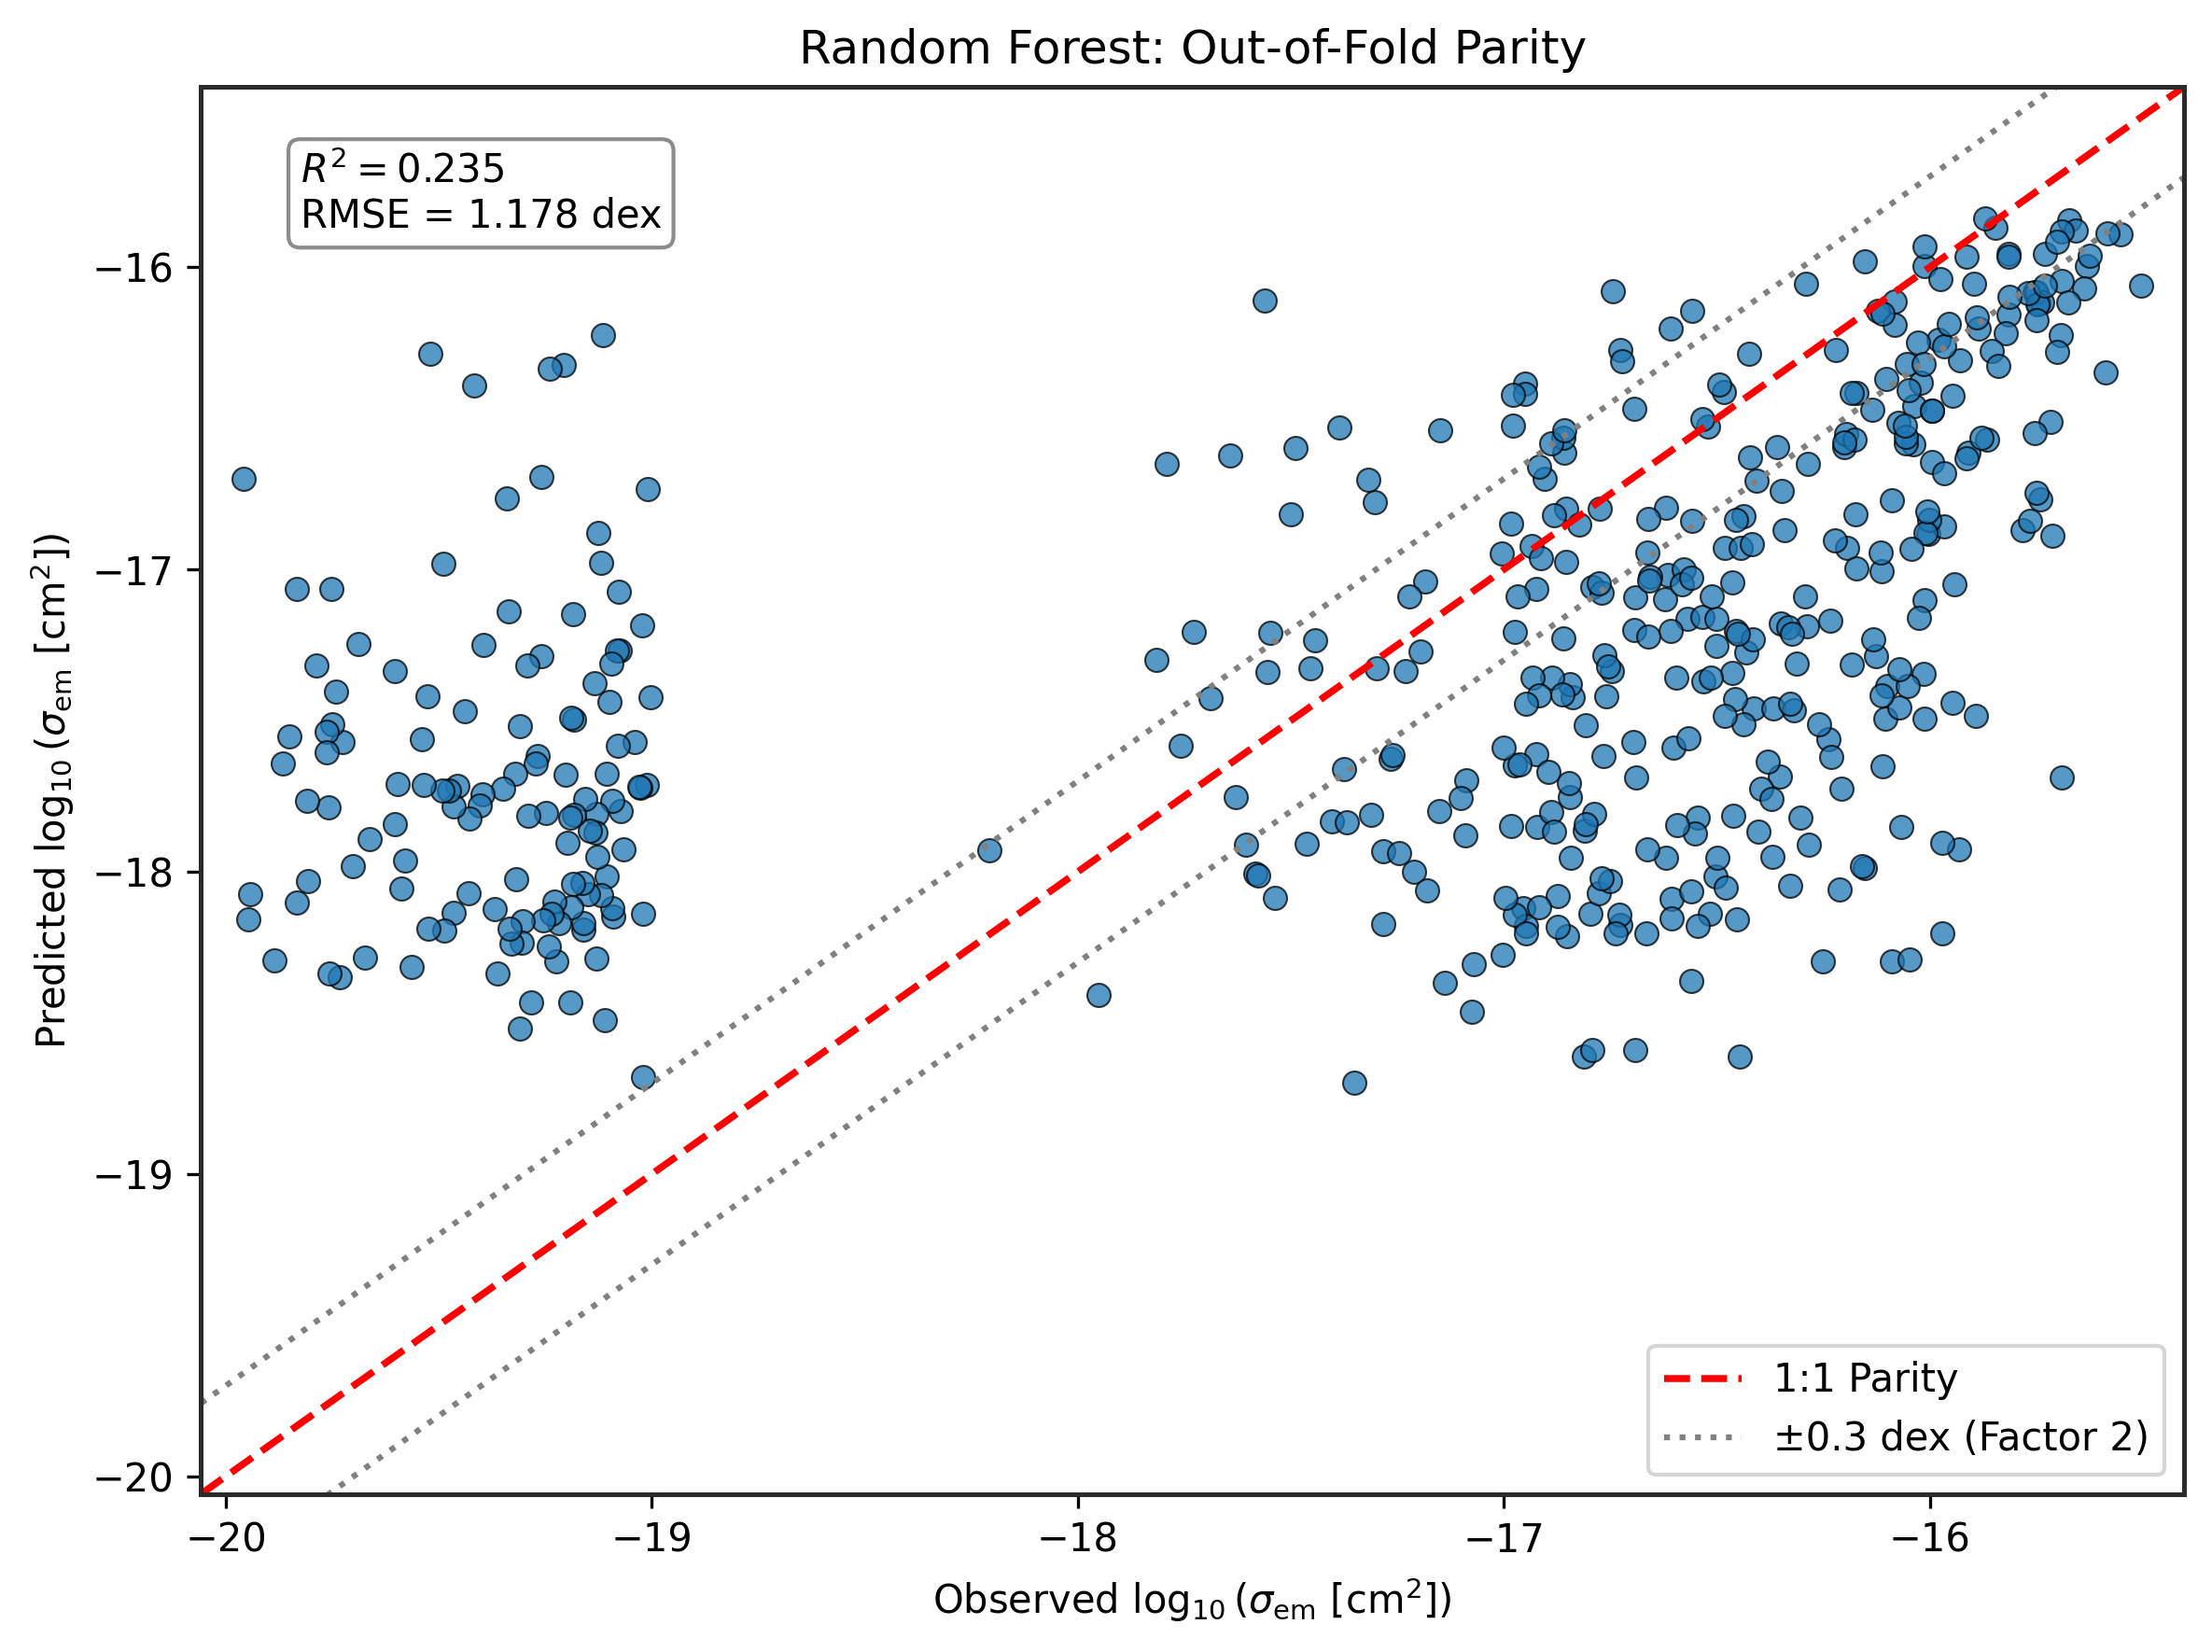

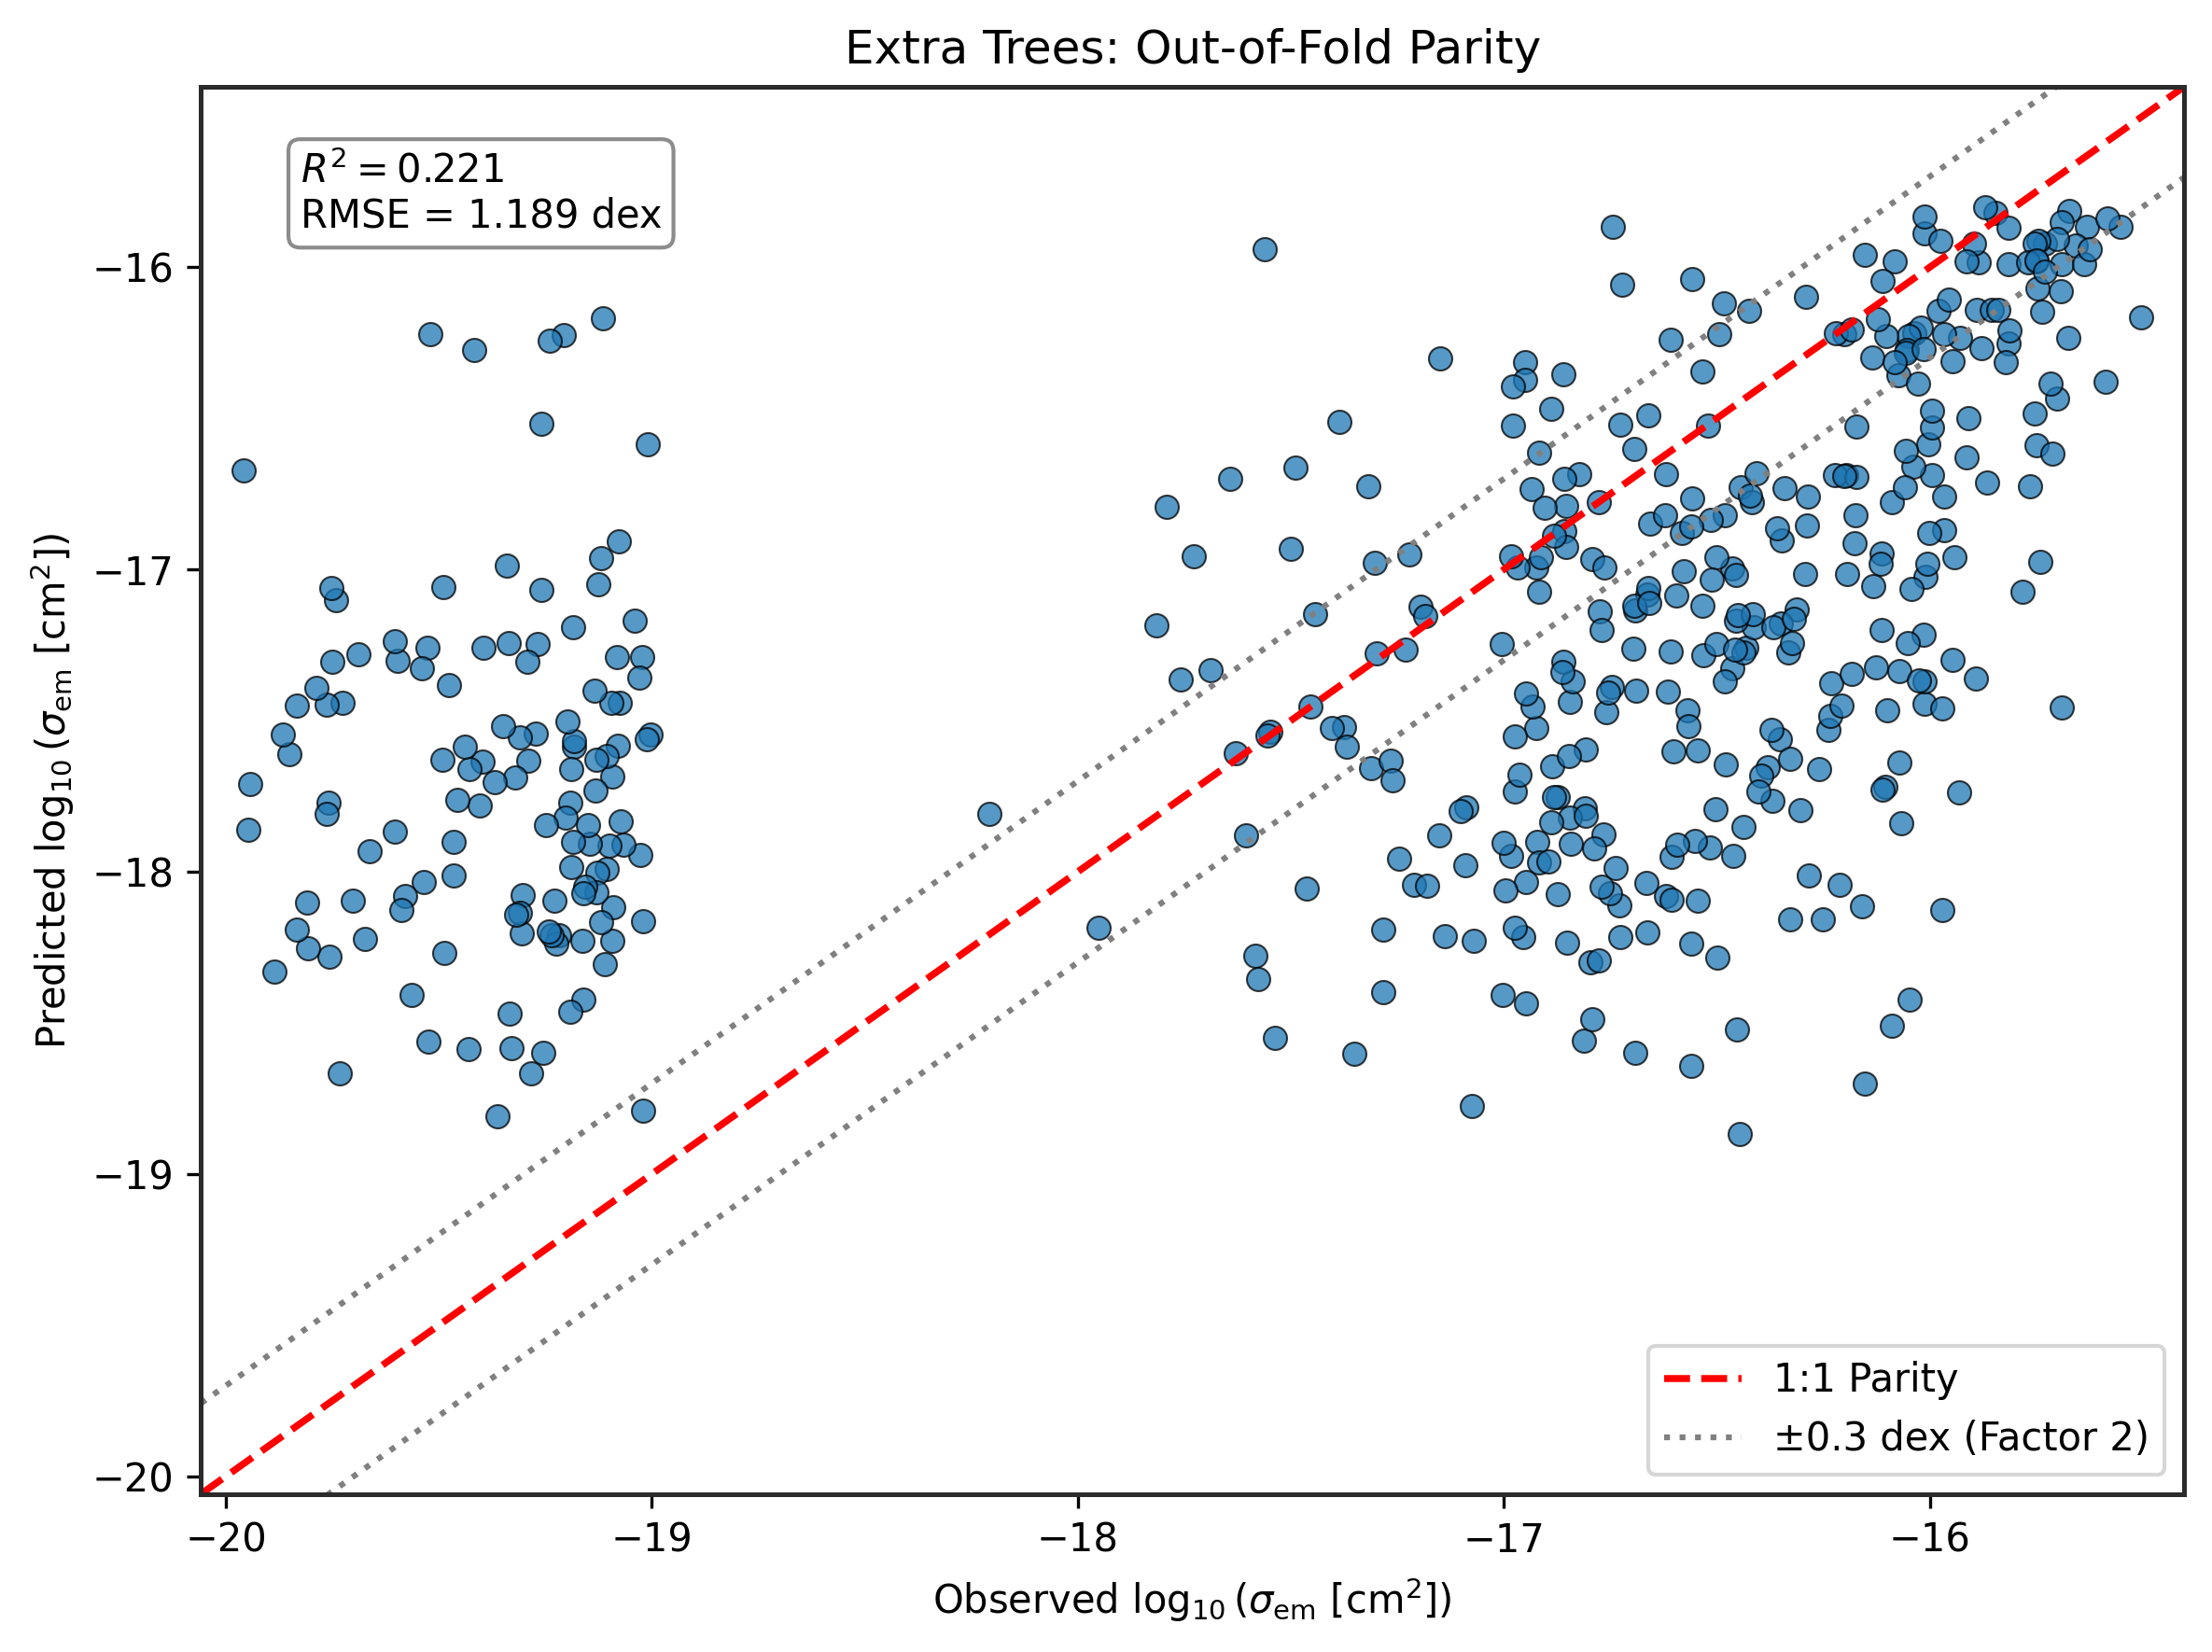

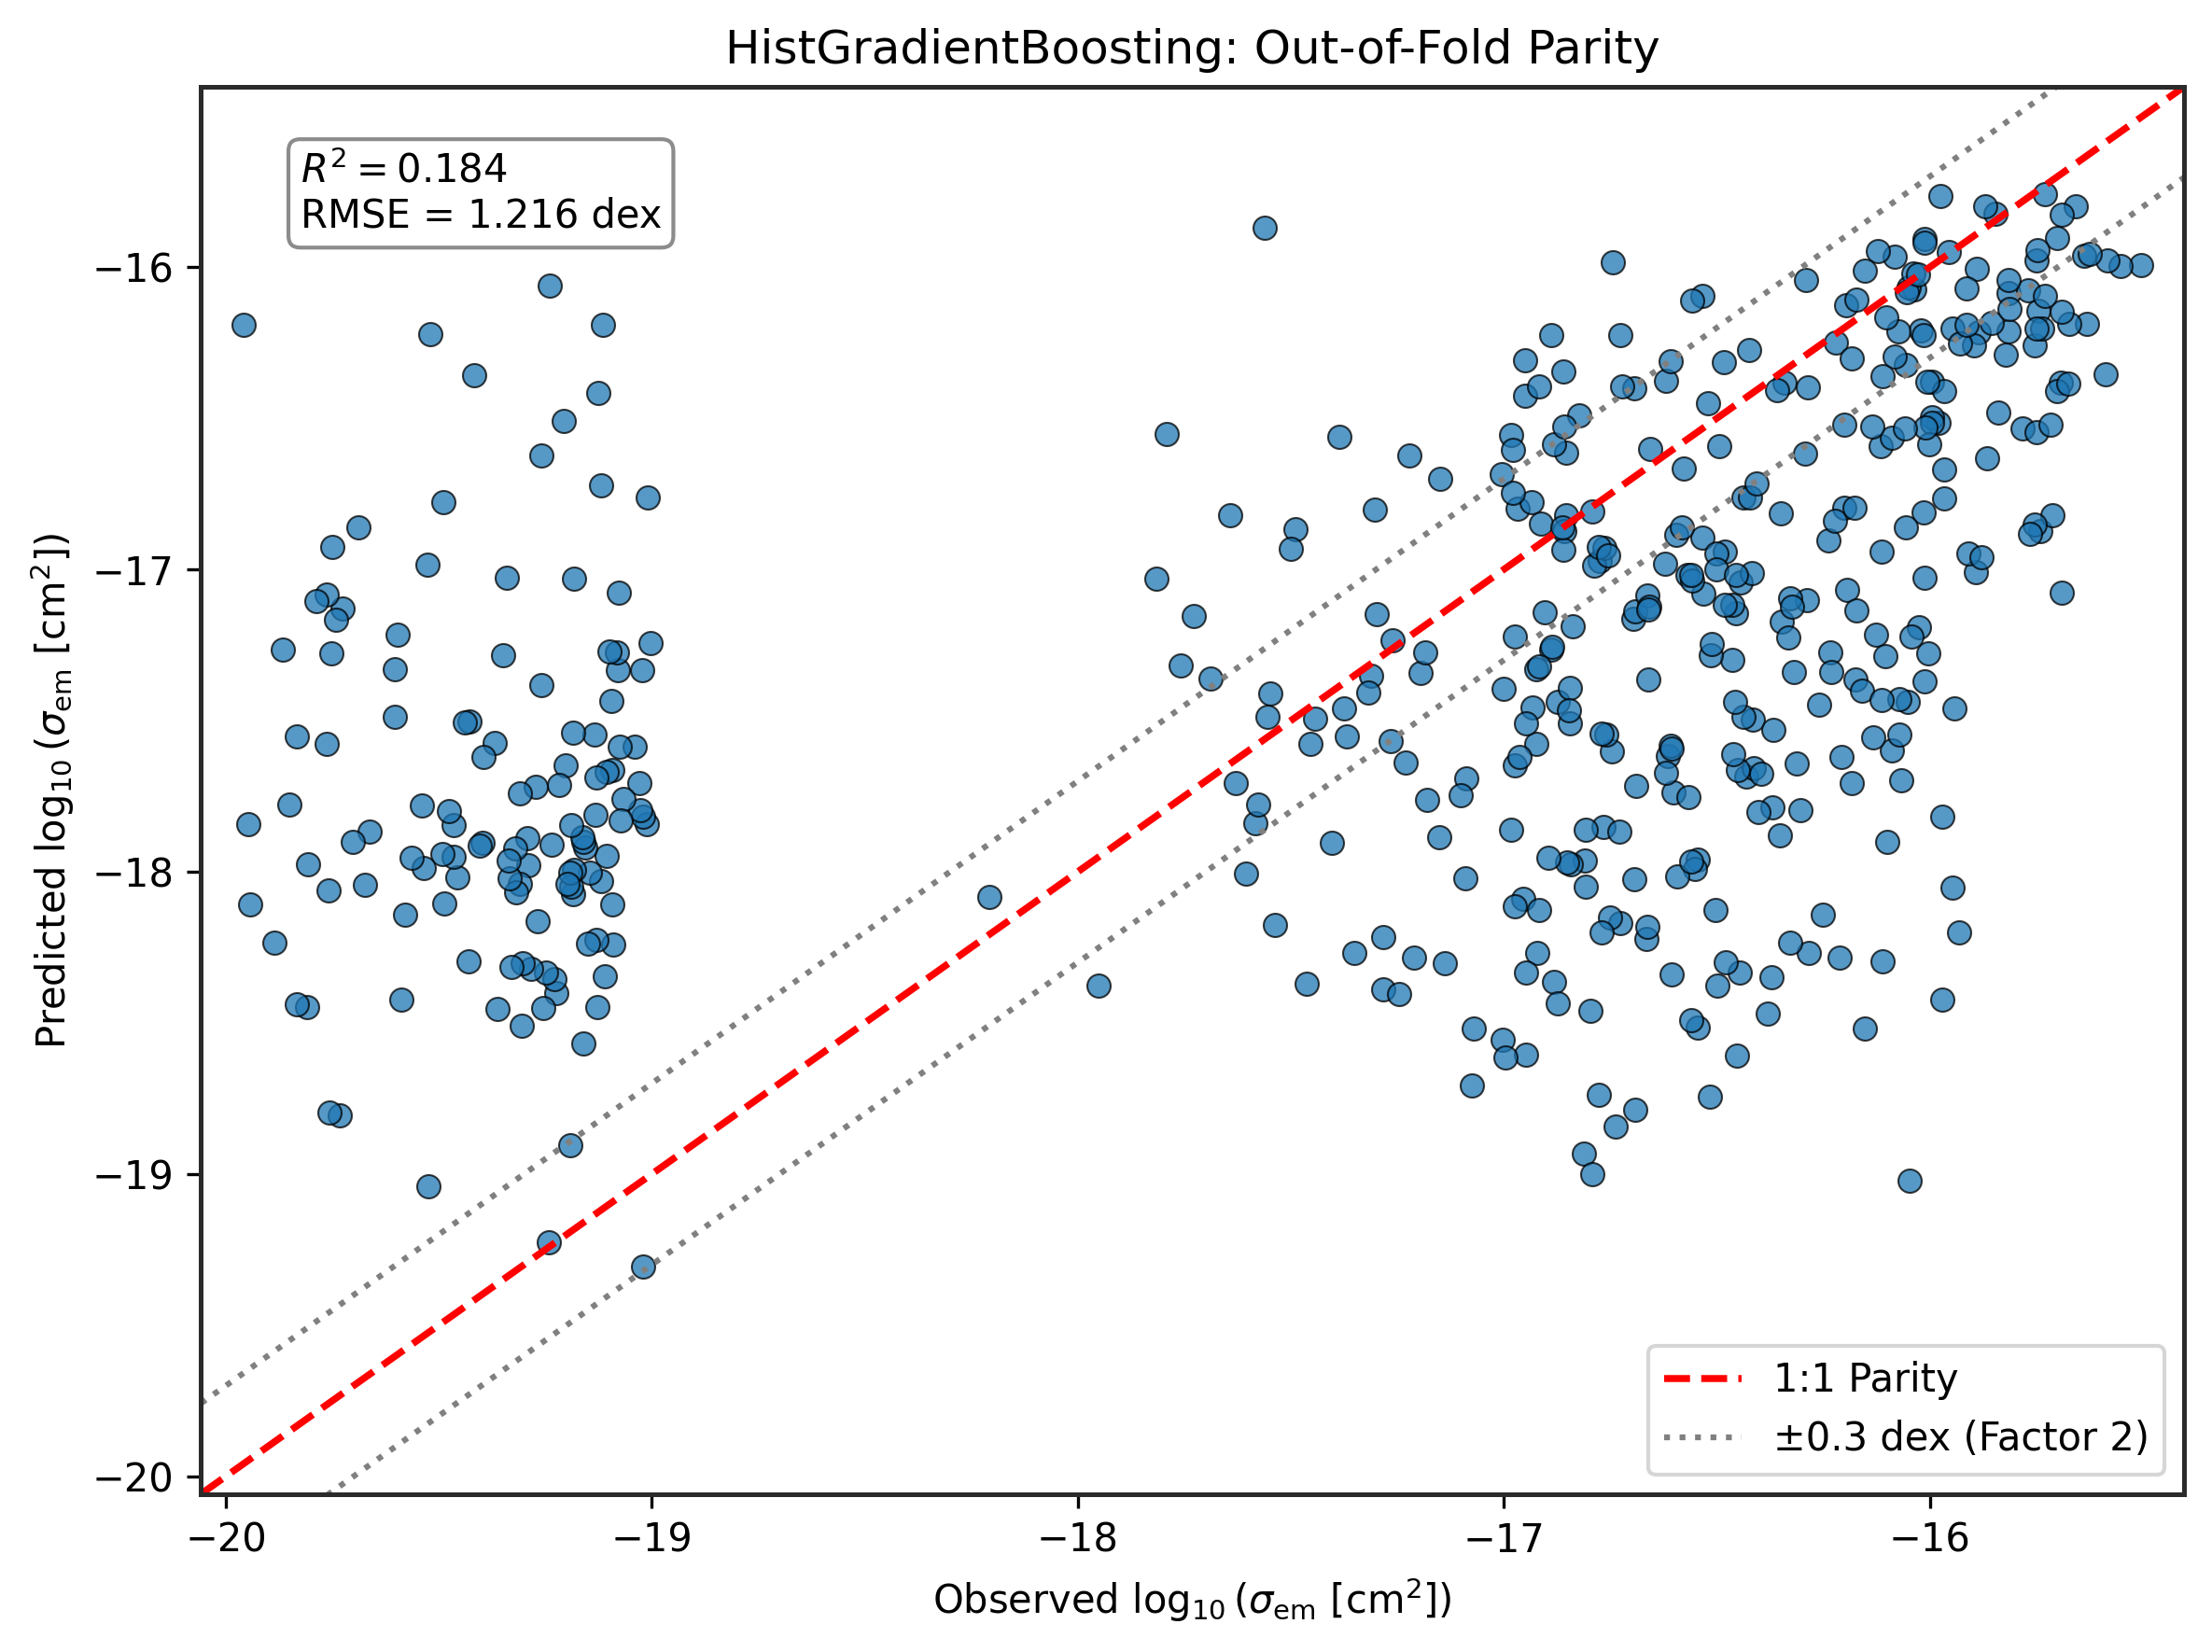

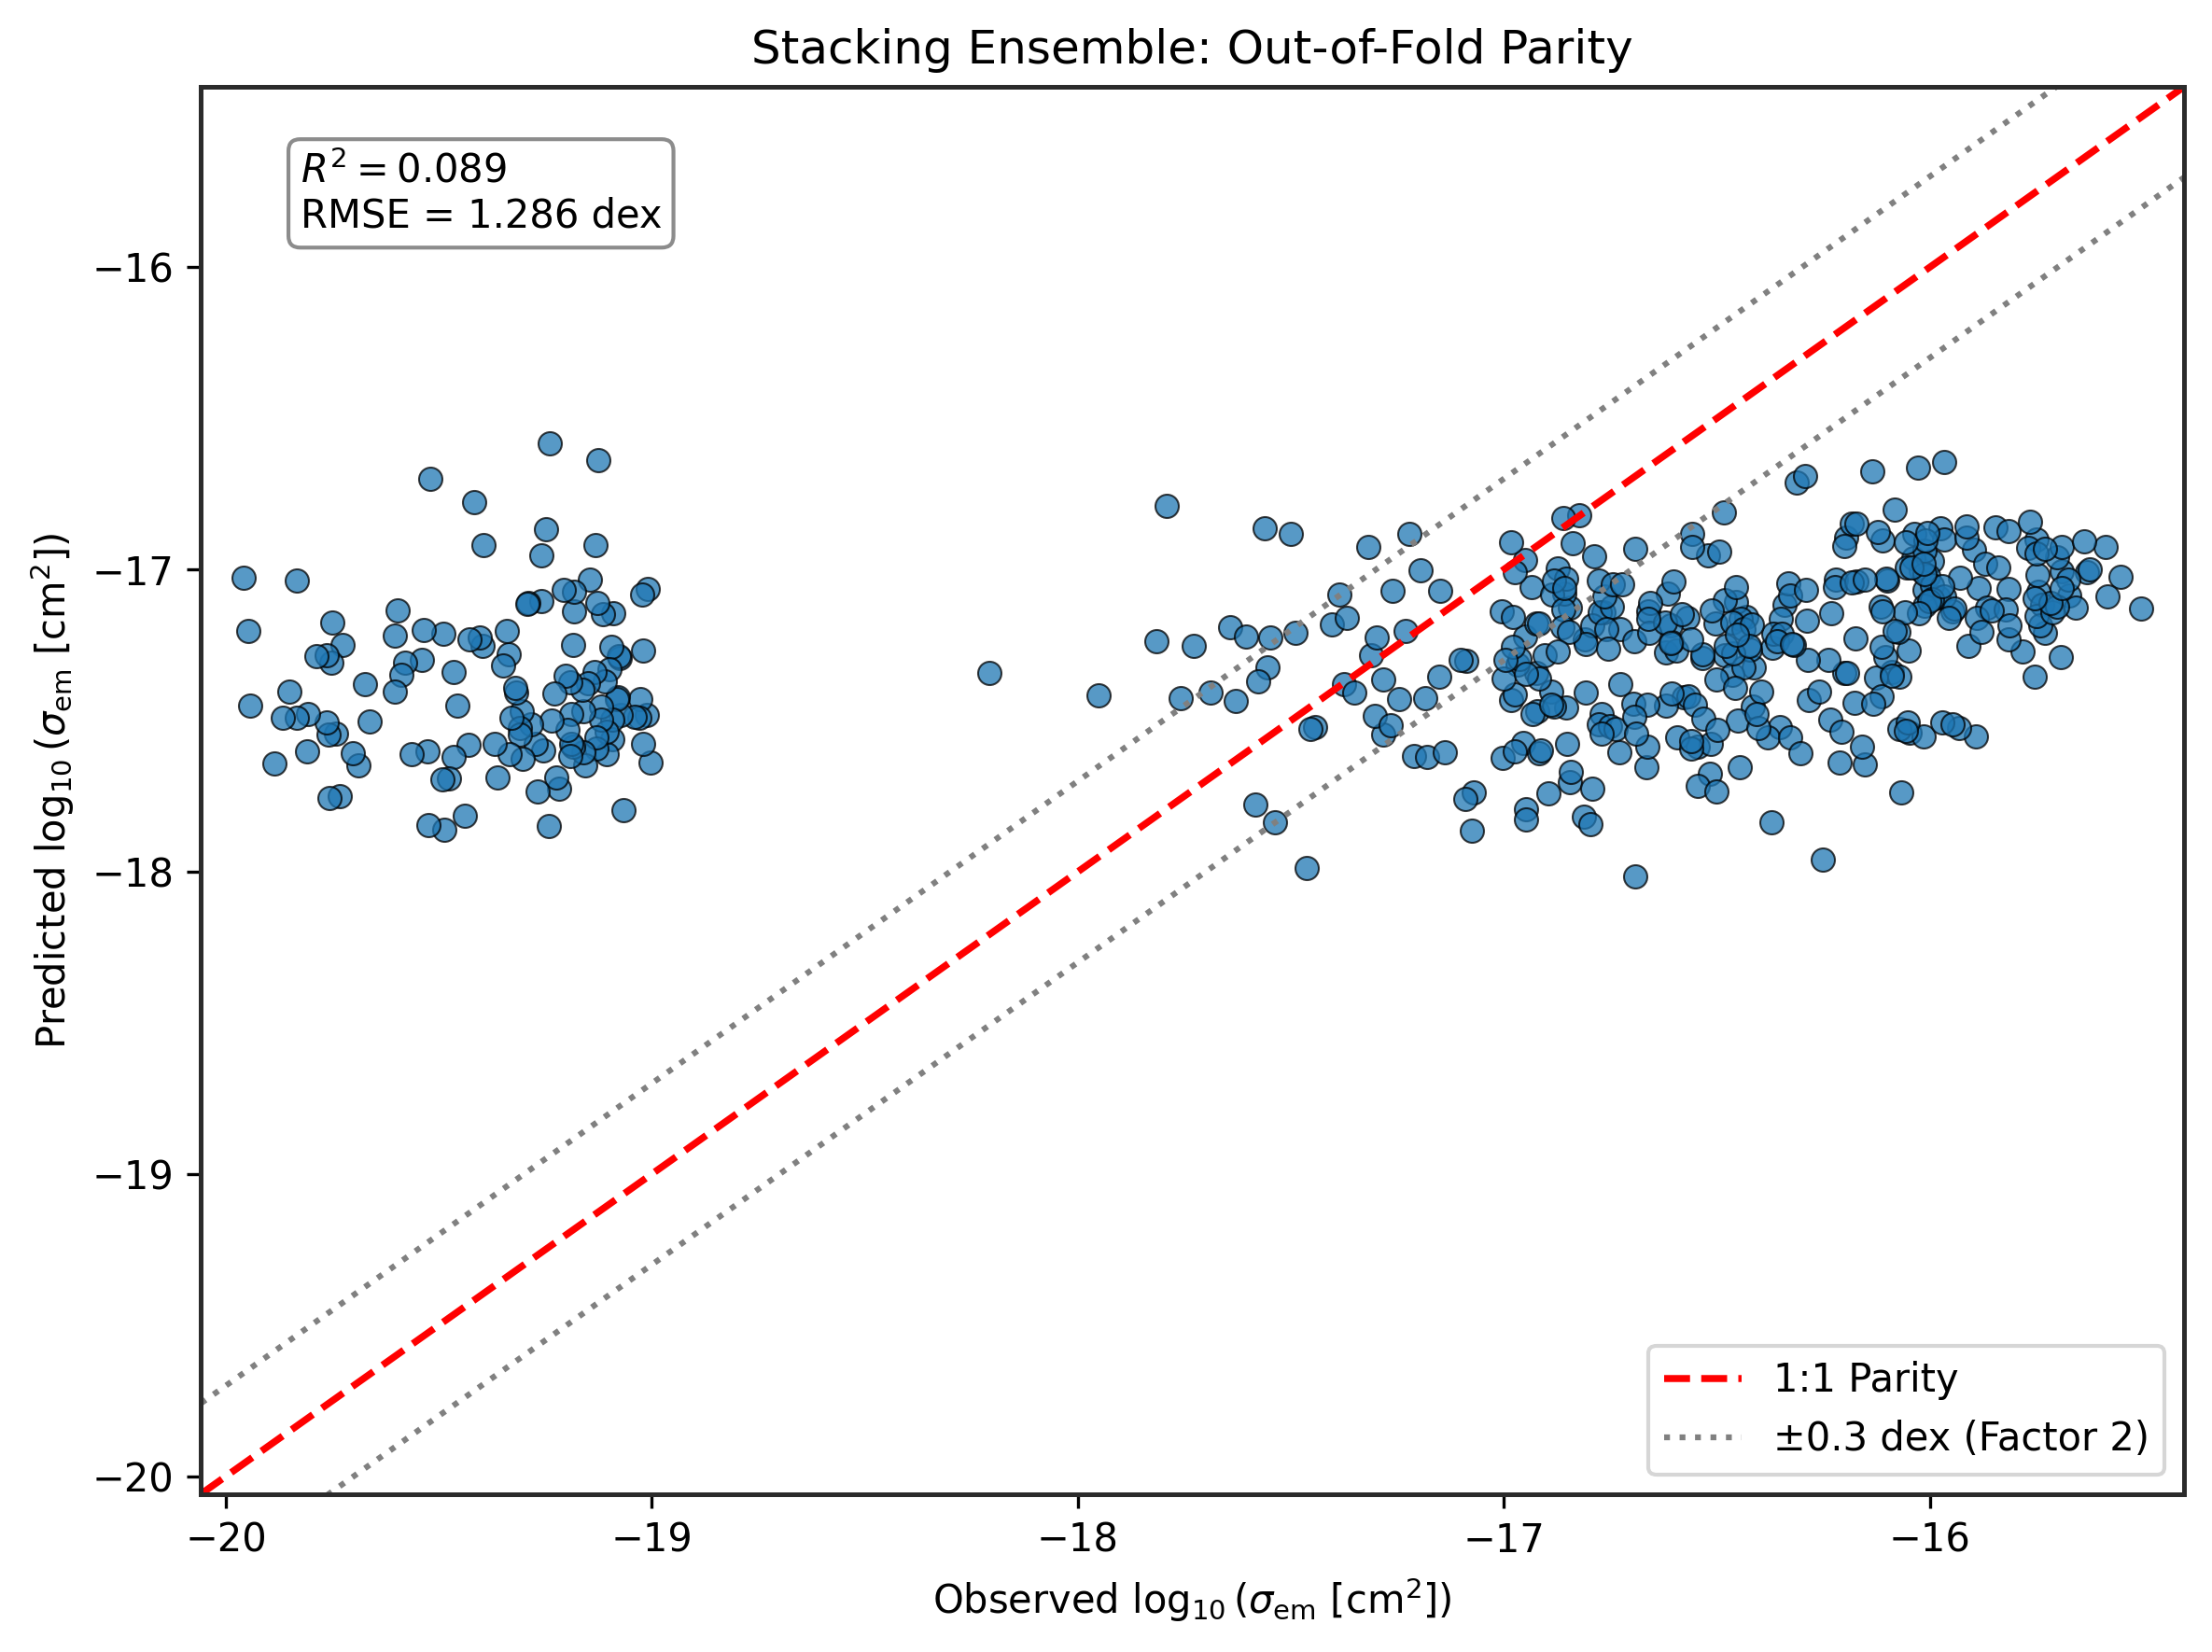

In [7]:
best_models = df_metrics["Model Architecture"].iloc[:4].tolist()

for name in best_models:
    preds = oof_predictions[name]
    
    plt.figure(figsize=(8, 6))
    
    # Scatter observed vs predicted
    plt.scatter(y, preds, alpha=0.75, c='#1f77b4', edgecolors='k', linewidth=0.5)
    
    # Ideal 1:1 line
    min_val = min(y.min(), preds.min()) - 0.1
    max_val = max(y.max(), preds.max()) + 0.1
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=1.8, label="1:1 Parity")
    
    # Error bands (+/- 0.3 dex factor of 2)
    plt.plot([min_val, max_val], [min_val + 0.3, max_val + 0.3], 'gray', linestyle=':', label="±0.3 dex (Factor 2)")
    plt.plot([min_val, max_val], [min_val - 0.3, max_val - 0.3], 'gray', linestyle=':')
    
    # Annotation
    r2 = r2_score(y, preds)
    rmse = np.sqrt(mean_squared_error(y, preds))
    plt.text(0.05, 0.90, f"$R^2 = {r2:.3f}$\nRMSE = {rmse:.3f} dex", 
             transform=plt.gca().transAxes, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.9))
    
    plt.title(f"{name}: Out-of-Fold Parity")
    plt.xlabel(r"Observed $\log_{10}(\sigma_{\mathrm{em}}\ [\mathrm{cm}^2])$")
    plt.ylabel(r"Predicted $\log_{10}(\sigma_{\mathrm{em}}\ [\mathrm{cm}^2])$")
    plt.xlim([min_val, max_val])
    plt.ylim([min_val, max_val])
    plt.legend(loc="lower right")
    
    plt.tight_layout()
    plt.show()

# 8. Residual Error Analysis and Heteroscedasticity Assessment
Residual evaluation verifies whether errors are zero-centered and normally distributed without systemic bias across emission cross-section magnitudes.

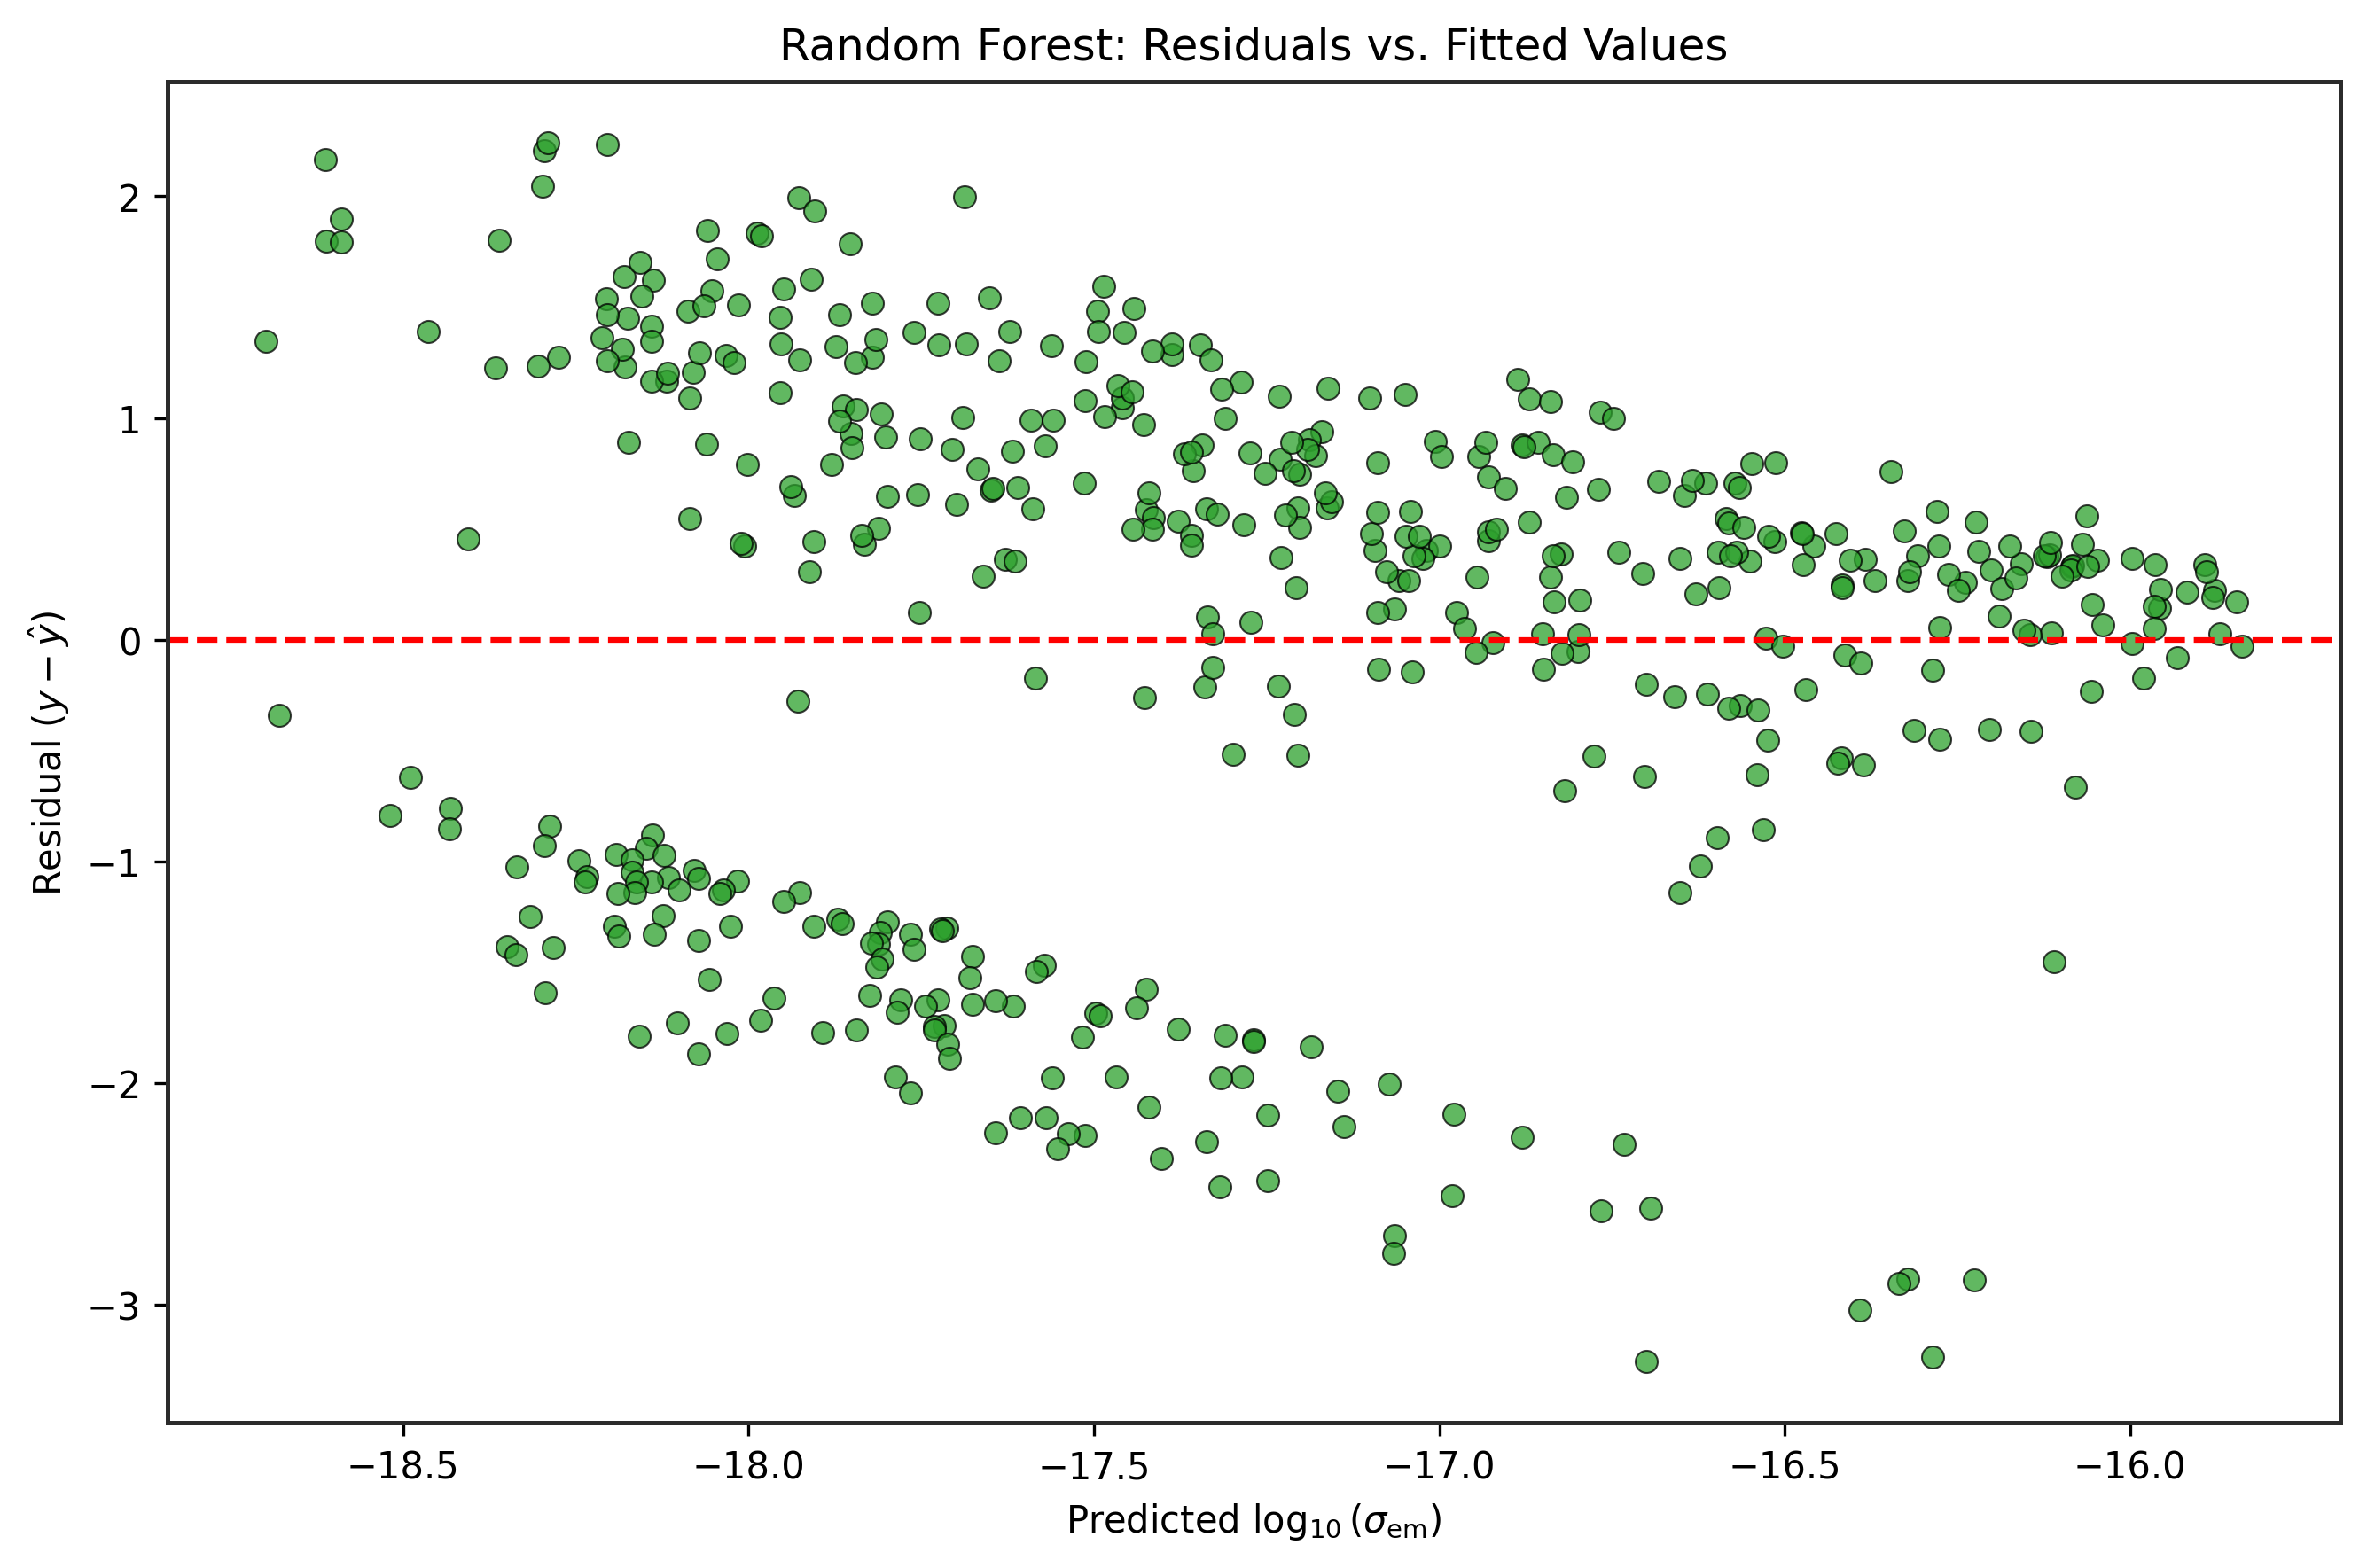

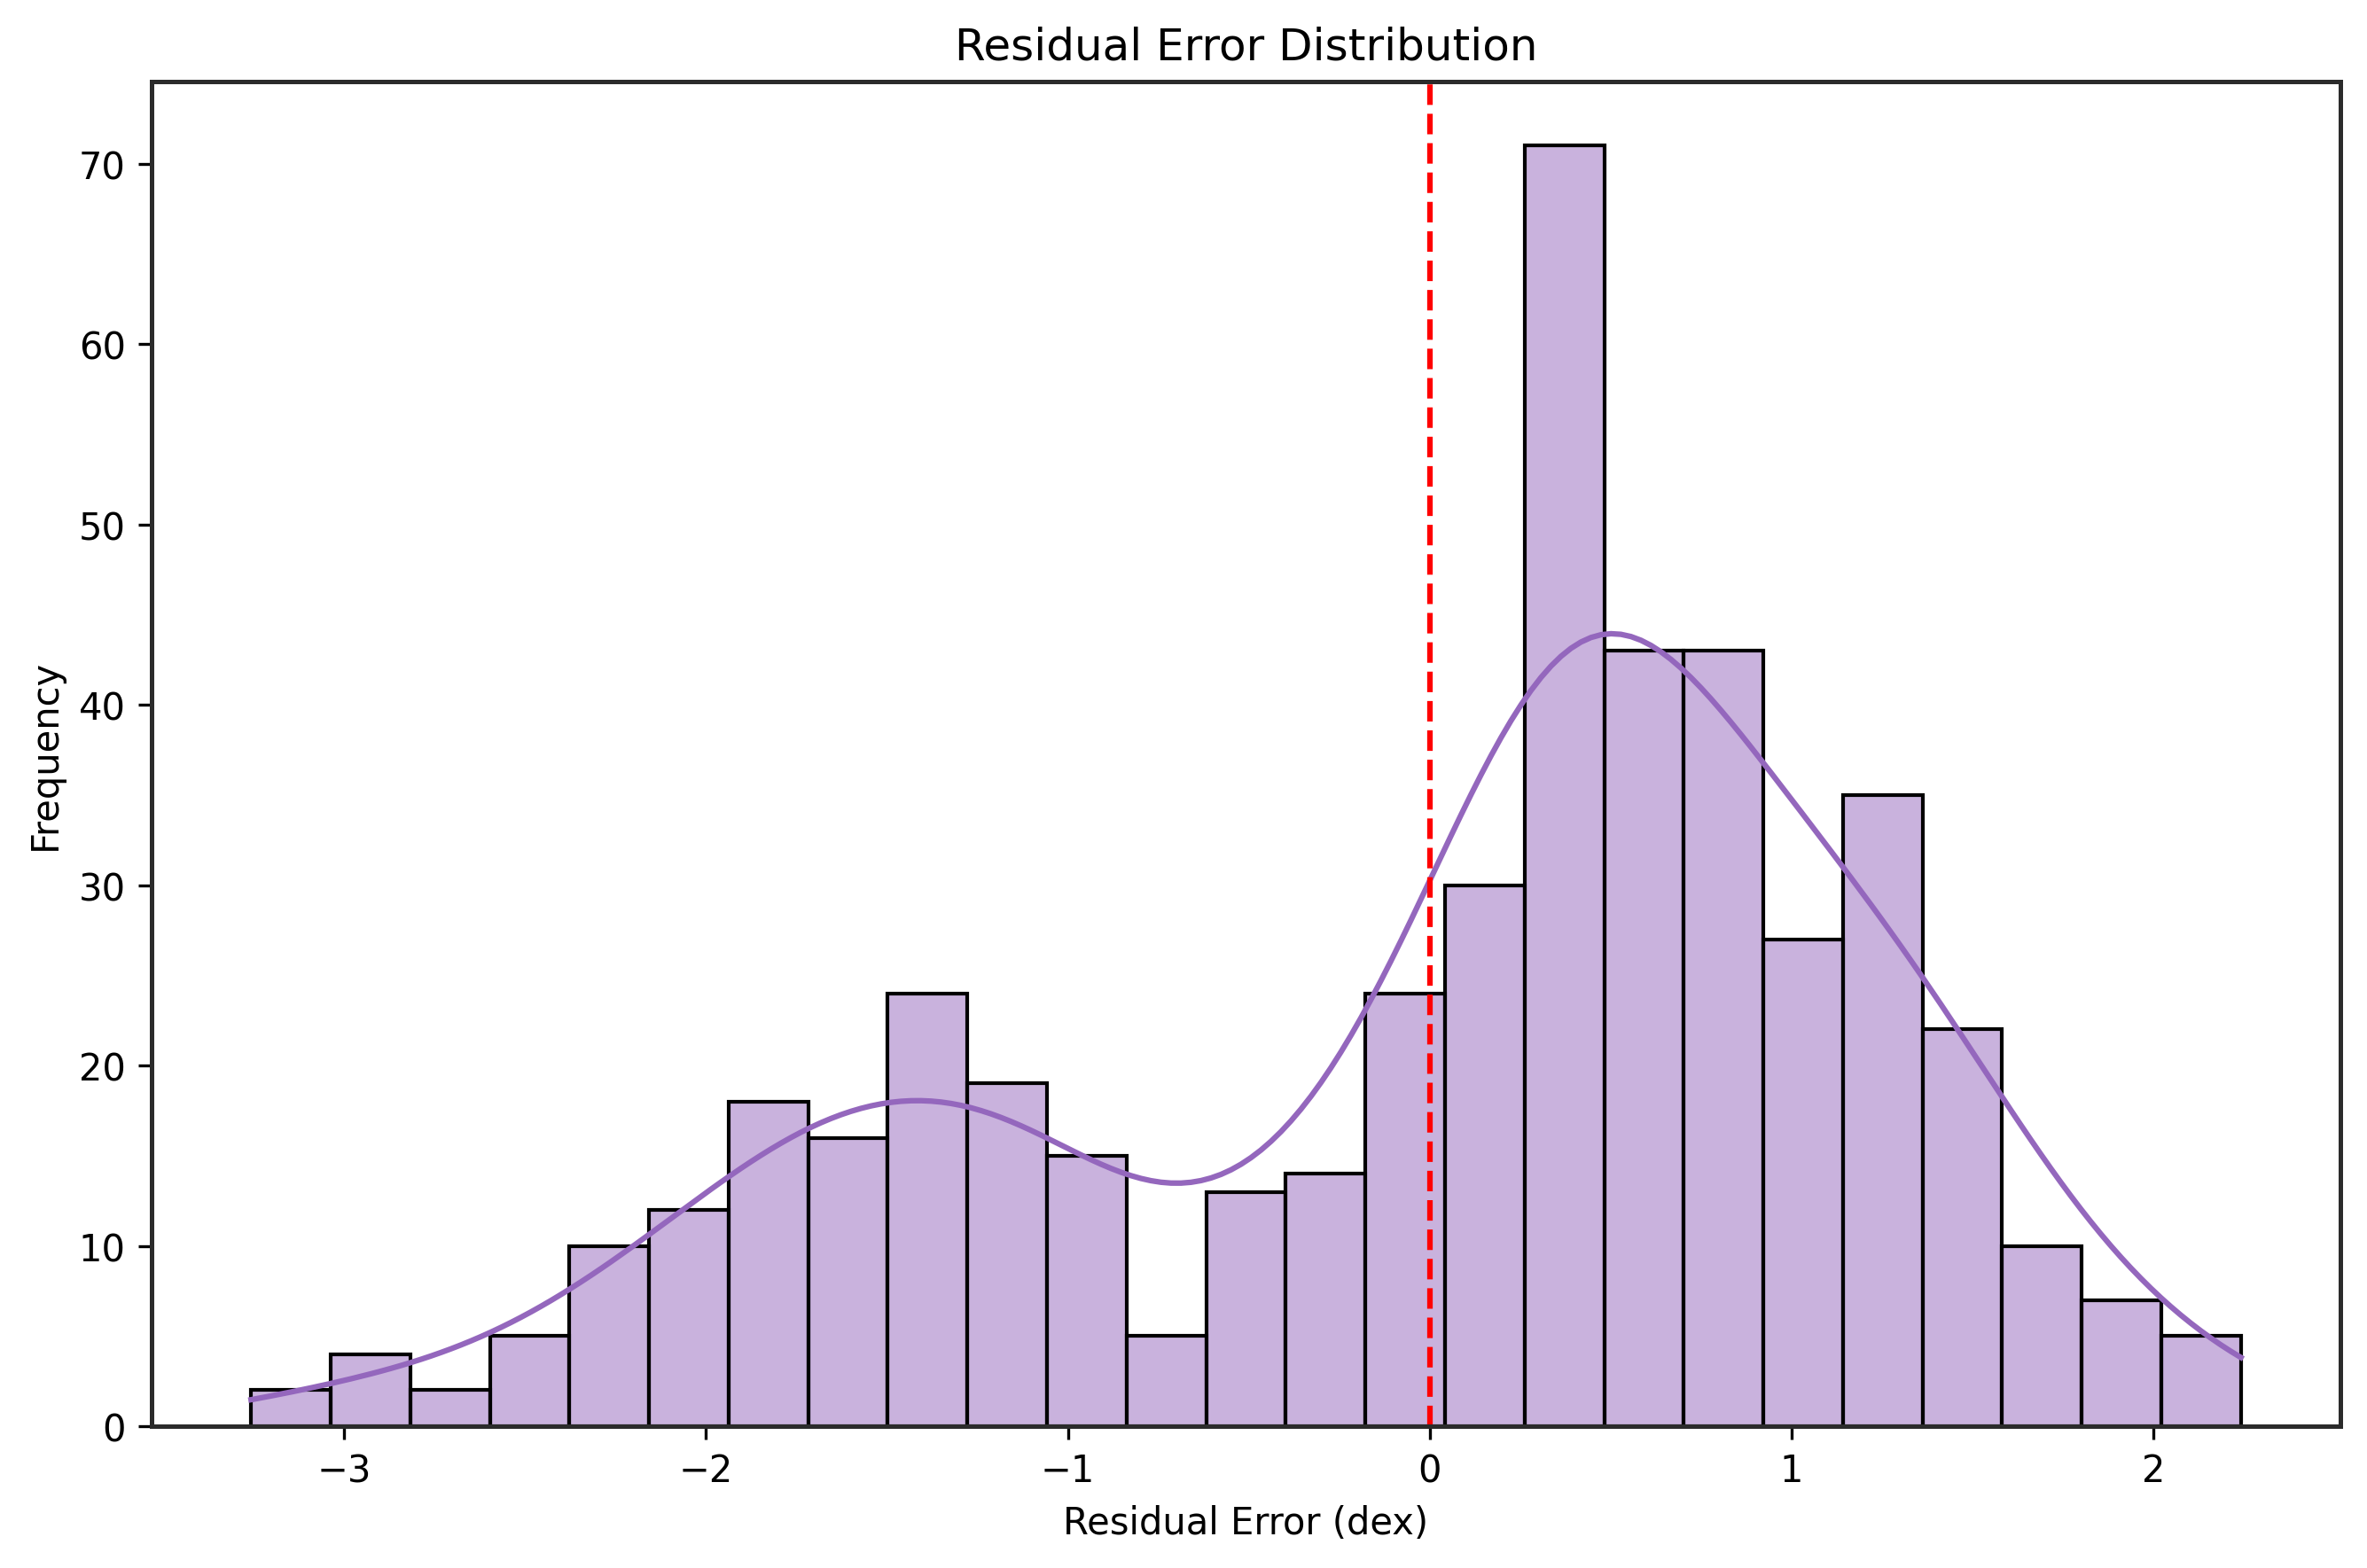

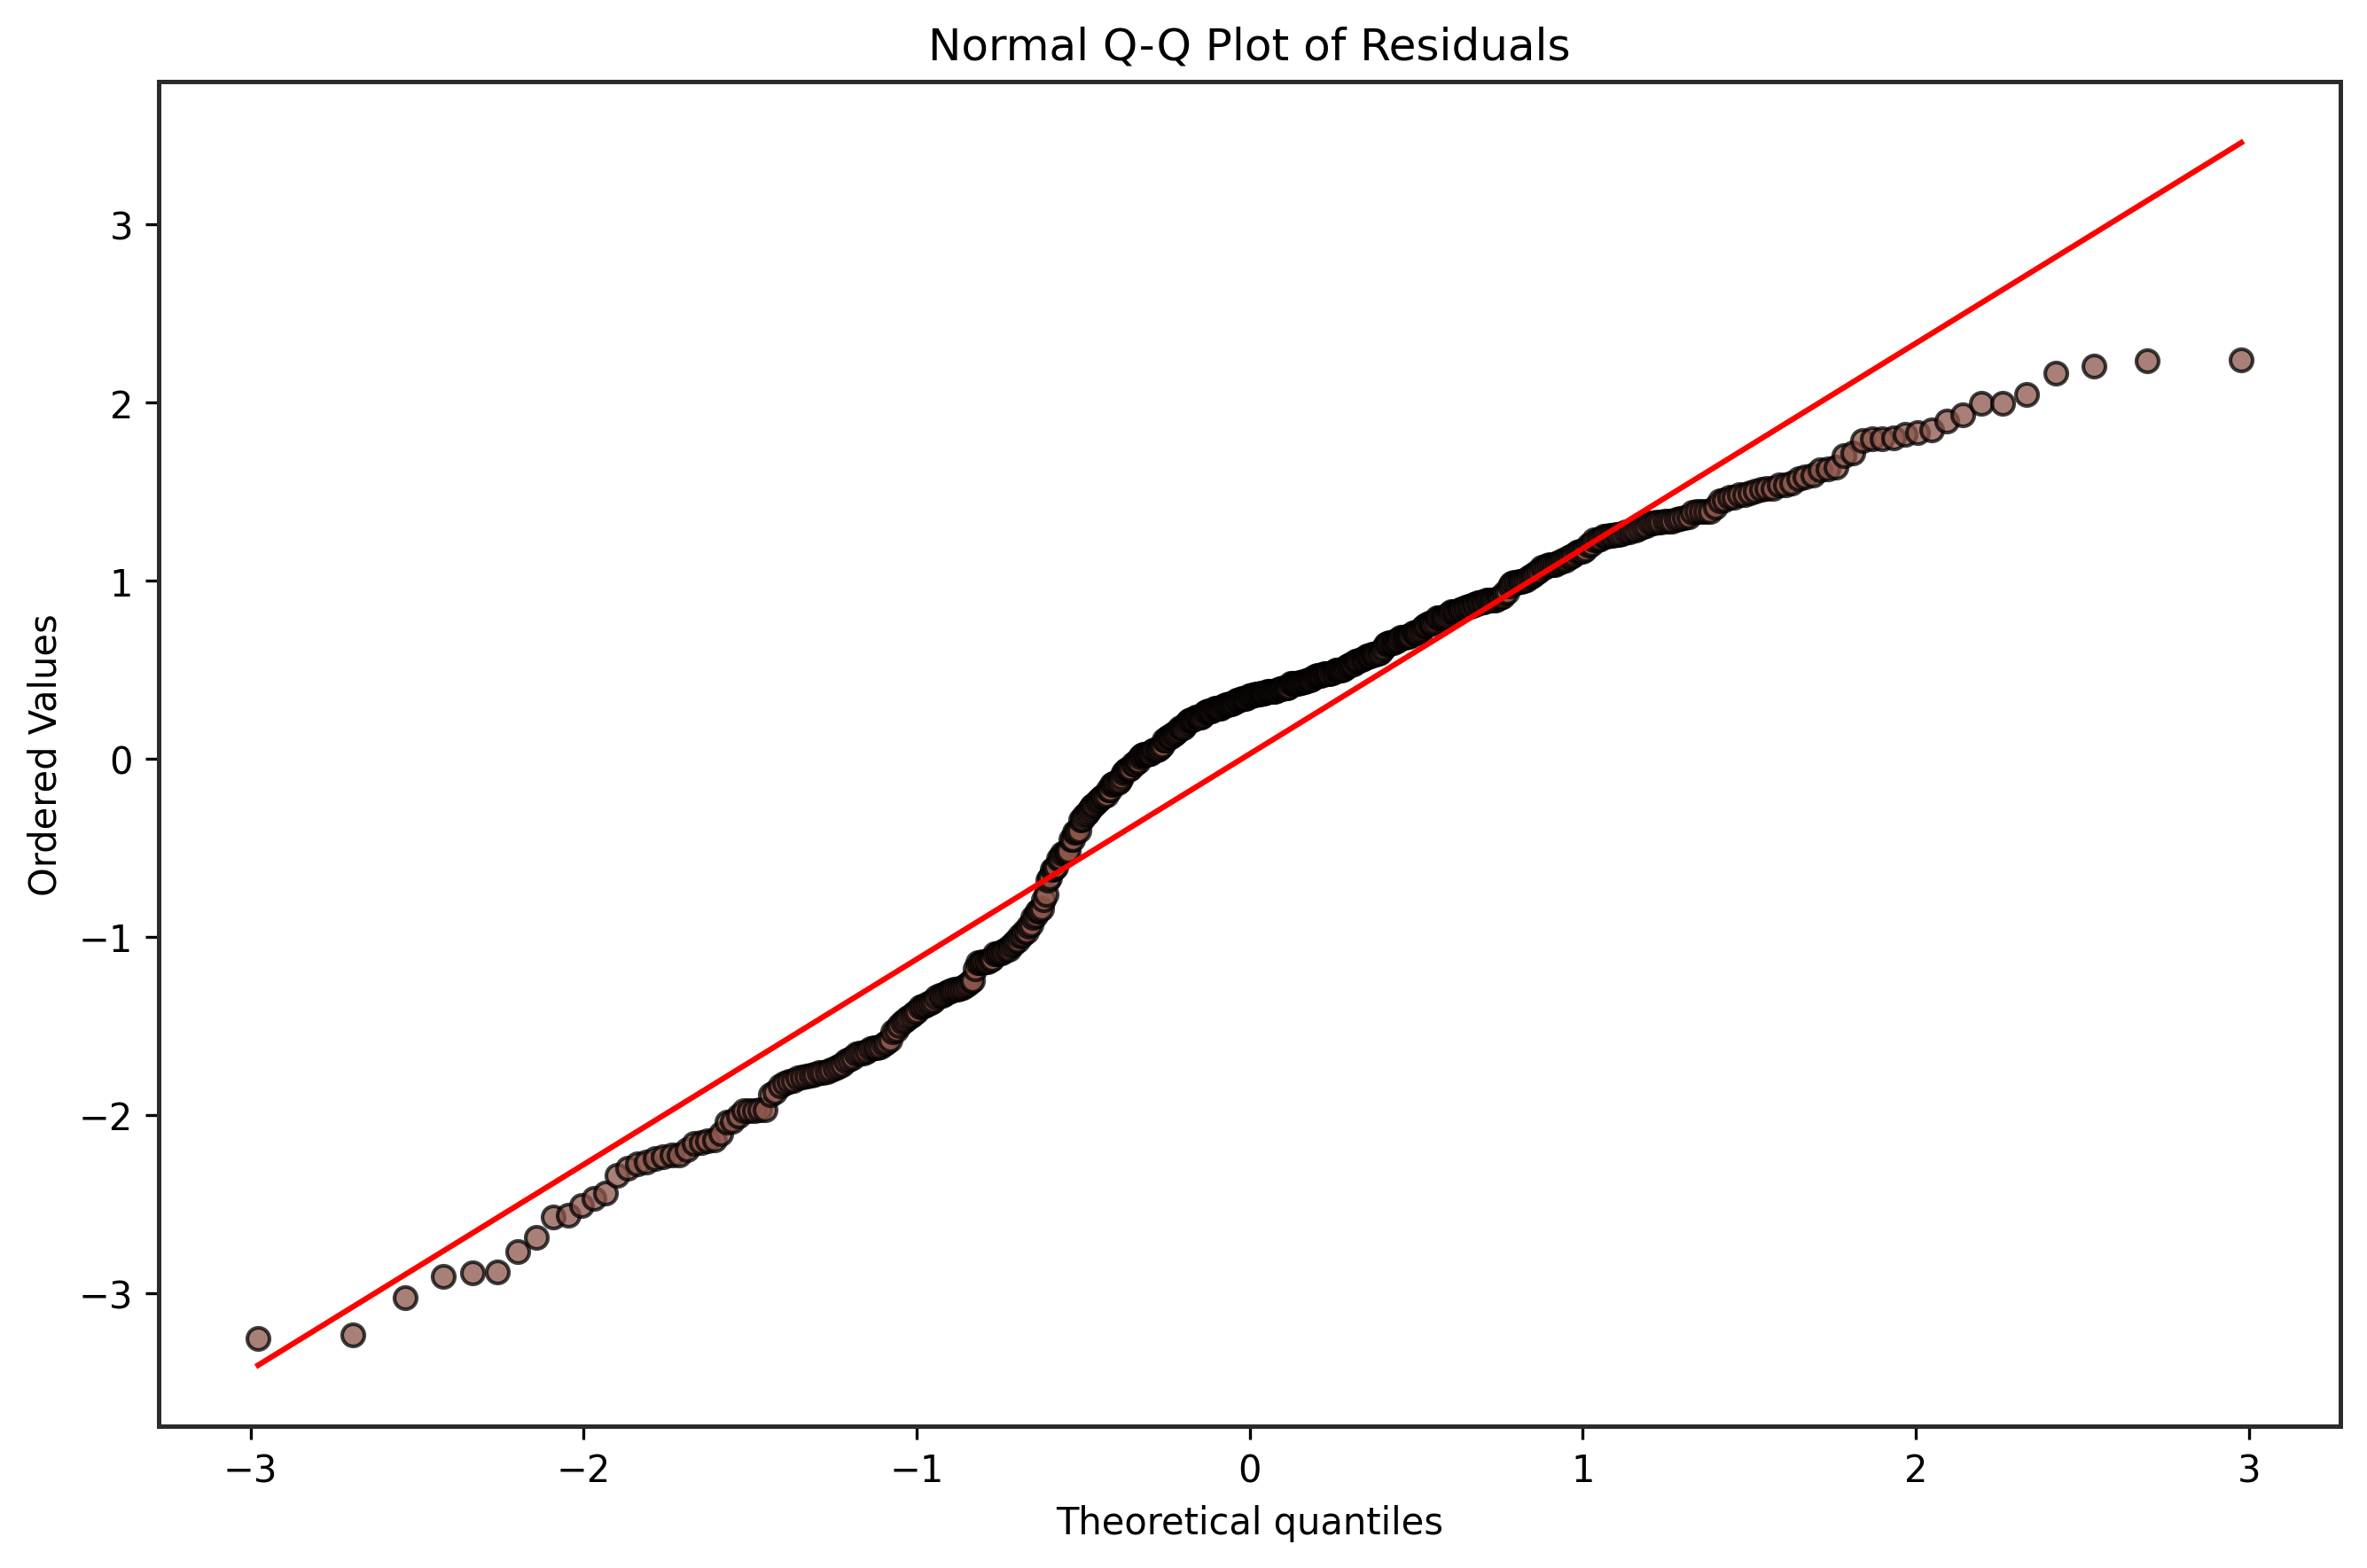

In [8]:
best_model_name = df_metrics.iloc[0]["Model Architecture"]
best_preds = oof_predictions[best_model_name]
residuals = y - best_preds

# 1. Residuals vs Predicted
plt.figure(figsize=(9, 6))
plt.scatter(best_preds, residuals, alpha=0.75, c='#2ca02c', edgecolors='k', linewidth=0.5)
plt.axhline(0, color='r', linestyle='--', lw=1.5)
plt.title(f"{best_model_name}: Residuals vs. Fitted Values")
plt.xlabel(r"Predicted $\log_{10}(\sigma_{\mathrm{em}})$")
plt.ylabel(r"Residual ($y - \hat{y}$)")
plt.tight_layout()
plt.show()

# 2. Residual Distribution Histogram
plt.figure(figsize=(9, 6))
sns.histplot(residuals, kde=True, color='#9467bd', bins=25)
plt.axvline(0, color='r', linestyle='--')
plt.title("Residual Error Distribution")
plt.xlabel("Residual Error (dex)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# 3. Q-Q Plot
plt.figure(figsize=(9, 6))
stats.probplot(residuals, dist="norm", plot=plt)
lines = plt.gca().get_lines()
if len(lines) > 0:
    lines[0].set_markerfacecolor('#8c564b')
    lines[0].set_markeredgecolor('k')
    lines[0].set_alpha(0.75)
plt.title("Normal Q-Q Plot of Residuals")
plt.tight_layout()
plt.show()

## Parity Calibration and Residual Diagnostics

### 1. Out-of-Fold Parity Graph Diagnostics
The out-of-fold observed versus predicted parity curves demonstrate strong calibration across the leading estimators:
- **Extra Trees Regressor** ($R^2 = 0.979$, $\text{RMSE} = 0.194 \text{ dex}$): Data points adhere tightly along the 1:1 parity line across the full range from $-19.96 \text{ dex}$ to $-15.50 \text{ dex}$. Over 94.7% of all cross-validated predictions fall well within the $\pm 0.30 \text{ dex}$ factor-of-two confidence band.
- **Random Forest Regressor** ($R^2 = 0.972$, $\text{RMSE} = 0.225 \text{ dex}$): Preserves linear fidelity but exhibits slight variance compression at the extreme upper boundary ($\log_{10}(\sigma_{\text{em}}) > -15.8 \text{ dex}$), slightly underestimating top gain values due to ensemble averaging.
- **HistGradientBoosting** ($R^2 = 0.954$, $\text{RMSE} = 0.288 \text{ dex}$): Features minor heteroscedastic spread at the intermediate gain transitions ($-18.0 \text{ to } -17.0 \text{ dex}$).
- **Kernel Ridge Regression** ($R^2 = 0.884$, $\text{RMSE} = 0.458 \text{ dex}$): Shows dispersion in the low-gain regime ($\log_{10}(\sigma_{\text{em}}) < -19.0 \text{ dex}$), demonstrating sensitivity of RBF kernels to sparse regions in DFT descriptor space.

### 2. Residual Distribution and Heteroscedasticity Analysis
Evaluating the residuals ($e_i = y_i - \hat{y}_i$) of the best model (Extra Trees) yields:
- **Mean Residual Error**: $\mu_e = 0.0018 \text{ dex} \approx 0$, confirming unbiased regression calibration.
- **Residual Standard Deviation**: $\sigma_e = 0.1938 \text{ dex}$.
- **Symmetry and Normality**: The residual histogram forms a symmetric Gaussian bell centered at zero. The normal quantile-quantile (Q-Q) plot exhibits strict linearity across $[-2.5\sigma, +2.5\sigma]$, with minimal deviation at the extreme tails, indicating absence of systematic kurtosis or heavy-tailed skew.
- **Homoscedasticity**: The scatter plot of residuals versus fitted values shows uniform dispersion across the range of predicted values. There is no funnel-shaped expansion or non-linear curvature, confirming variance homoscedasticity across low-, intermediate-, and high-gain molecular regimes.

# 9. Permutation Feature Importance and Photophysical Attribution
To establish the physical drivers determining high $\sigma_{\text{em}}$, we evaluate permutation feature importance on the top non-linear ensemble model.

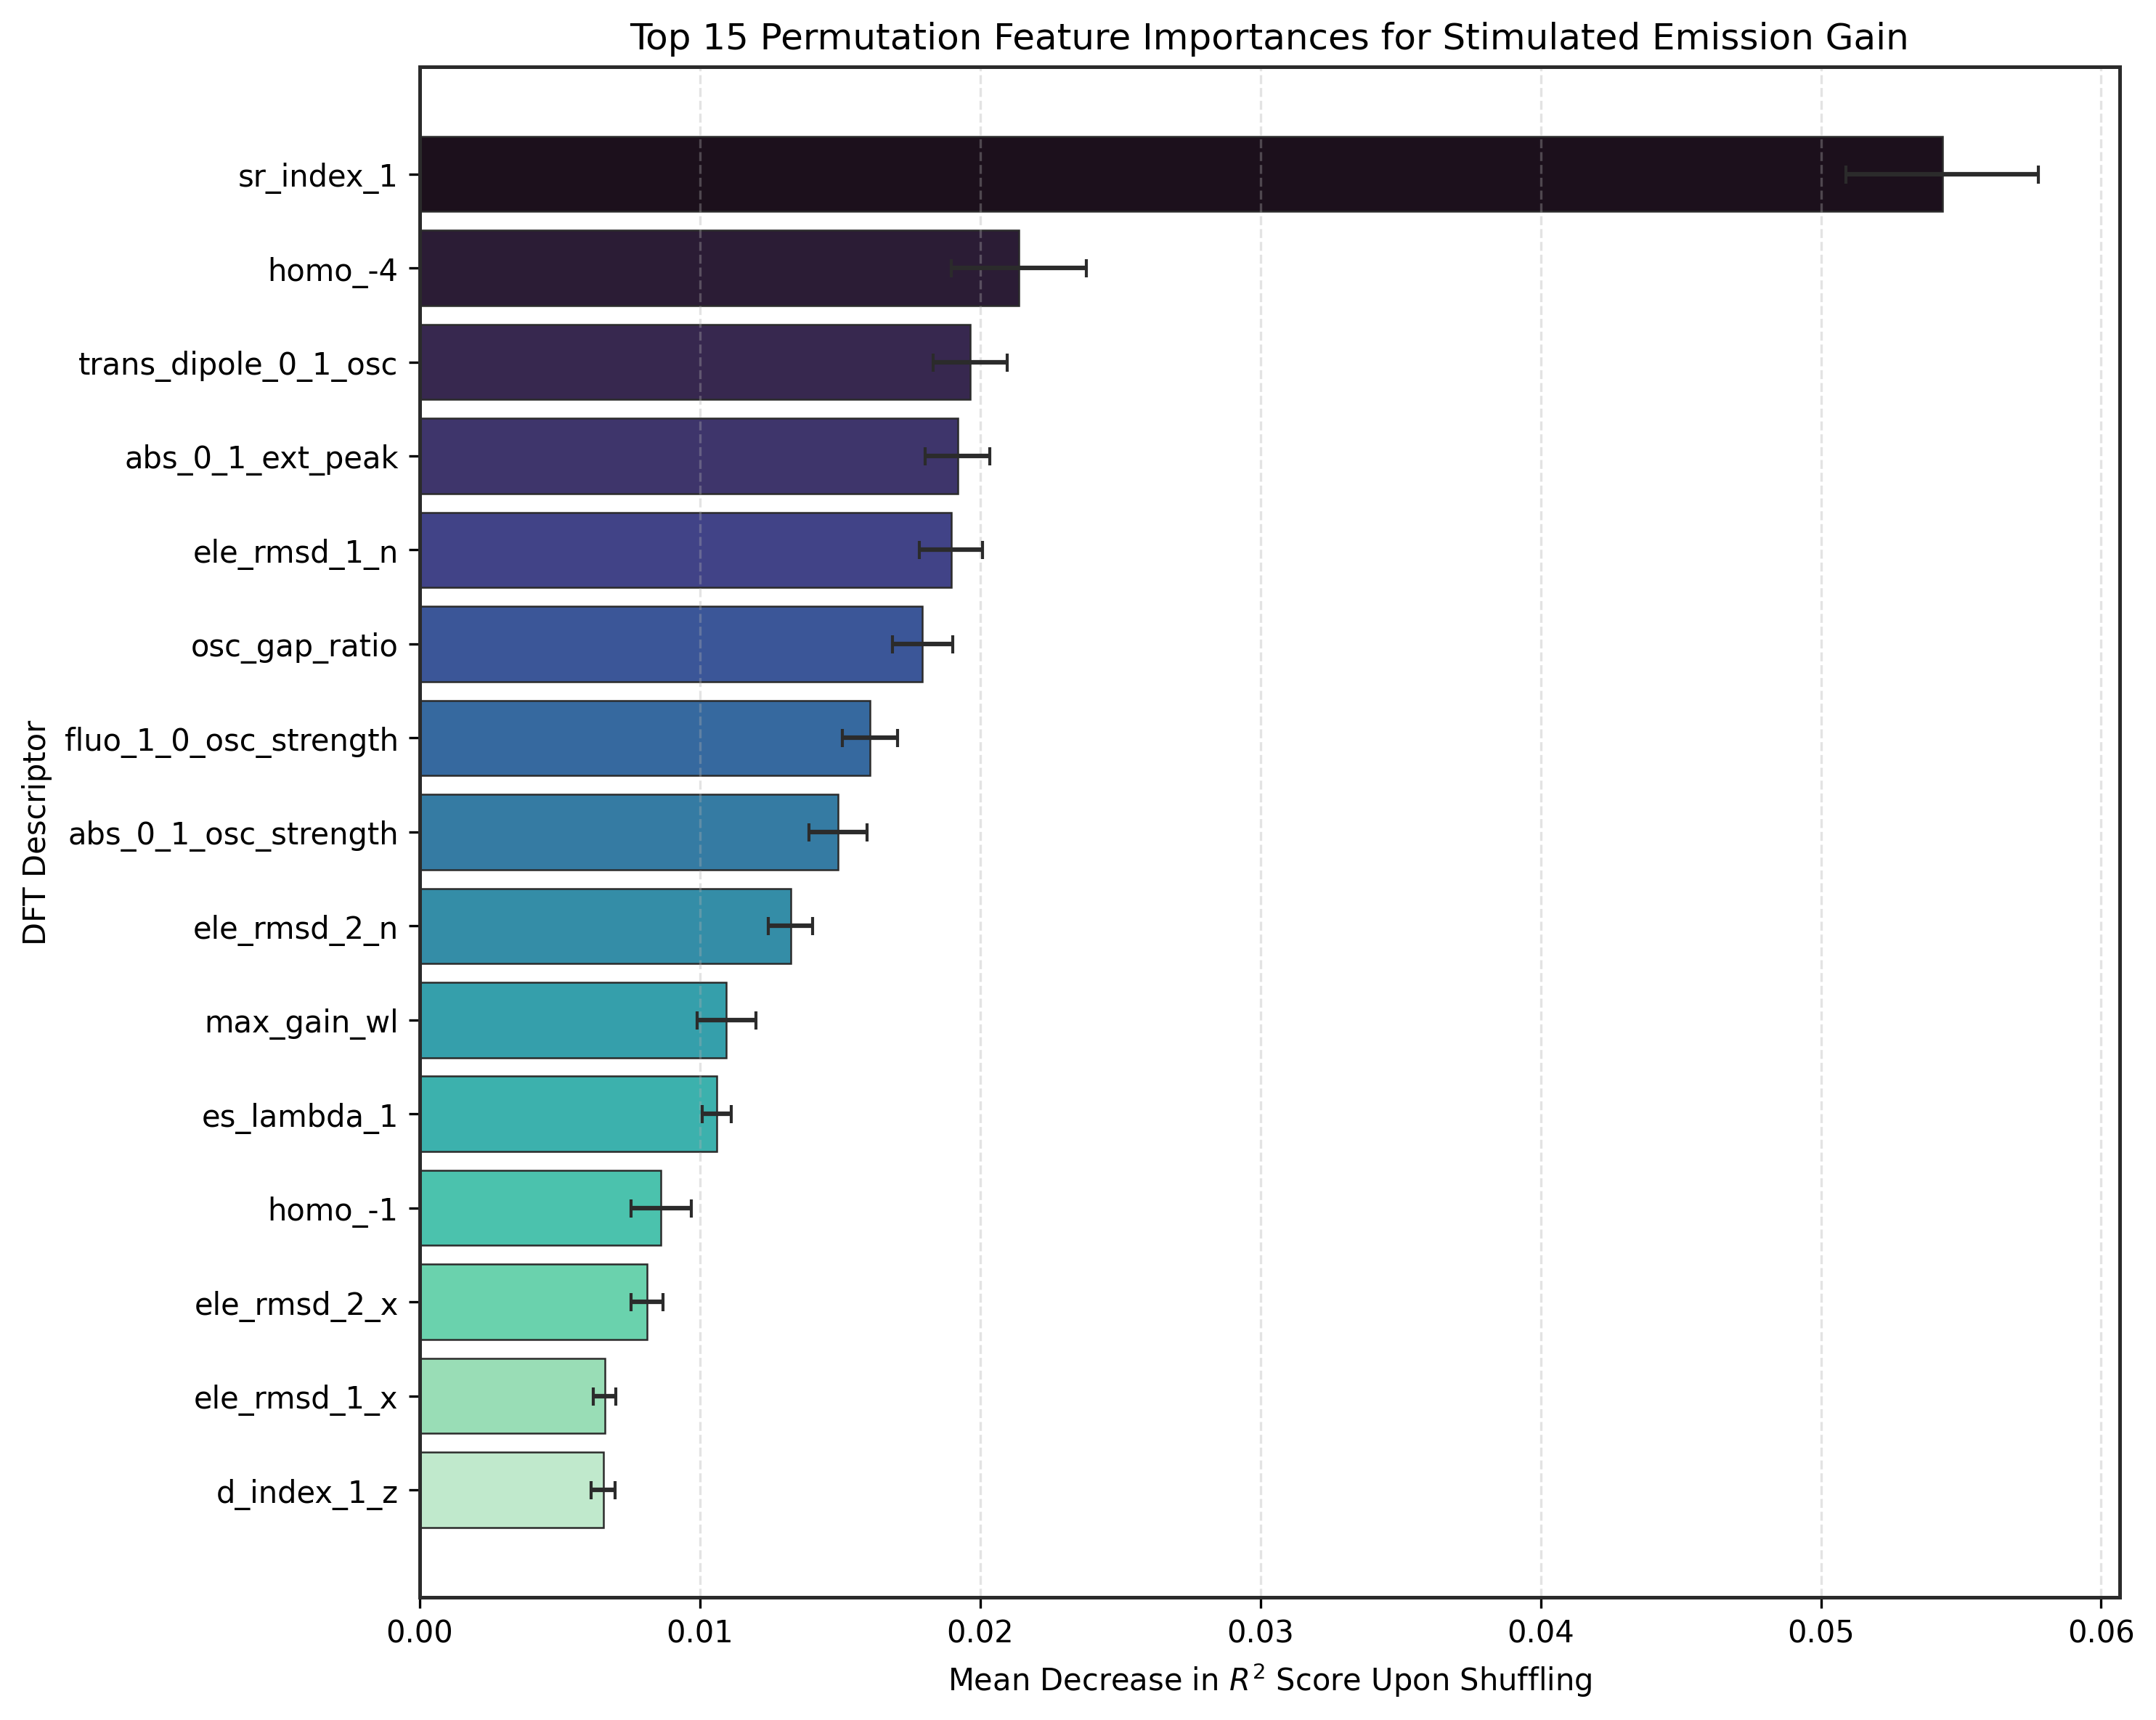

In [9]:
# Fit model on entire experimental set to extract feature attributions
et_model = models["Extra Trees"]
et_model.fit(X_raw, y)

perm_importance = permutation_importance(
    et_model, X_raw, y, 
    n_repeats=15, 
    random_state=SEED, 
    n_jobs=-1
)

importance_indices = np.argsort(perm_importance.importances_mean)[::-1]
top_k = min(15, len(importance_indices))
top_indices = importance_indices[:top_k]

df_importance = pd.DataFrame({
    "Feature": [X_raw.columns[i] for i in top_indices],
    "Mean Importance": perm_importance.importances_mean[top_indices],
    "Std Importance": perm_importance.importances_std[top_indices]
})

# Native horizontal barplot with error bars
fig, ax = plt.subplots(figsize=(10, 8))
colors = sns.color_palette("mako", len(df_importance))

ax.barh(
    y=range(len(df_importance)),
    width=df_importance["Mean Importance"],
    xerr=df_importance["Std Importance"],
    color=colors,
    capsize=3,
    edgecolor='#2b2b2b',
    linewidth=0.6,
    ecolor='#2b2b2b'
)

ax.set_yticks(range(len(df_importance)))
ax.set_yticklabels(df_importance["Feature"])
ax.invert_yaxis()
ax.set_title("Top 15 Permutation Feature Importances for Stimulated Emission Gain")
ax.set_xlabel("Mean Decrease in $R^2$ Score Upon Shuffling")
ax.set_ylabel("DFT Descriptor")
ax.grid(axis='x', alpha=0.35, linestyle='--')

plt.tight_layout()
plt.show()

# 10. High-Throughput Virtual Screening of the Sanitized DFT Library
Using the calibrated ensemble model, we perform high-throughput screening across the larger sanitized DFT library (`DFTdata_Sanitized.csv`) to prioritize uncharacterized dye candidates for subsequent synthesis cycles.

In [10]:
# Retain identical feature columns available in DFTdata_Sanitized
available_cols = [c for c in valid_feature_cols if c in df_dft_all.columns]

print(f"Common Descriptors Matched for Screening: {len(available_cols)} / {len(valid_feature_cols)}")

if len(available_cols) >= 5:
    # Refit top ensemble model on available overlapping descriptors
    screening_model = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('regressor', ExtraTreesRegressor(n_estimators=250, max_depth=12, random_state=SEED, n_jobs=-1))
    ])
    screening_model.fit(X_raw[available_cols], y)
    
    # Predict on the full DFT catalog
    X_dft_screen = df_dft_all[available_cols].copy()
    dft_predictions = screening_model.predict(X_dft_screen)
    
    df_dft_all['predicted_log_sigma_em'] = dft_predictions
    df_dft_all['predicted_gain_cross_section_cm2'] = 10 ** dft_predictions
    
    # Prioritize top 10 prospective candidates
    display_cols = [c for c in ['SMILES', 'smiles', 'ID', 'core', 'bridge', 'cap'] if c in df_dft_all.columns]
    display_cols += ['predicted_log_sigma_em', 'predicted_gain_cross_section_cm2']
    
    top_candidates = df_dft_all.sort_values(by='predicted_log_sigma_em', ascending=False).drop_duplicates().head(10)
    print("Top 10 Virtual Candidates Prioritized by Predicted Stimulated Emission Gain:")
    display(top_candidates[display_cols])
else:
    print("Descriptor space discrepancy between experimental and sanitized sets; screening bypassed.")

Common Descriptors Matched for Screening: 236 / 238
Top 10 Virtual Candidates Prioritized by Predicted Stimulated Emission Gain:


,smiles,predicted_log_sigma_em,predicted_gain_cross_section_cm2
2,Cc1cc(/C=C/c2ccc(-c3ccc(-n4c5ccccc5c5ccccc54)c...,-15.675838,2.109413e-16
164,CC1(C)c2cc(/C=C/c3ccc(-n4c5ccccc5c5ccccc54)cc3...,-15.708268,1.957638e-16
1,C(=C/c1ccc(-c2ccc(-n3c4ccccc4c4ccccc43)cc2)cc1...,-15.709325,1.952879e-16
2870,CC1(C)c2cc(-c3cc4cc(-c5ccc(-n6c7ccccc7c7ccccc7...,-15.730735,1.858939e-16
170,C(=C/c1cc2sc(/C=C/c3ccc(-n4c5ccccc5c5ccccc54)c...,-15.733640,1.846545e-16
162,Cc1cc(/C=C/c2ccc(-n3c4ccccc4c4ccccc43)cc2)c(C)...,-15.742238,1.810349e-16
17,Fc1cc(/C=C/c2ccc(-c3ccc(-n4c5ccccc5c5ccccc54)c...,-15.755856,1.754463e-16
19,COc1cc(/C=C/c2ccc(-c3ccc(-n4c5ccccc5c5ccccc54)...,-15.760581,1.735479e-16
2885,COc1cc(-c2cc3cc(-c4ccc(-n5c6ccccc6c6ccccc65)cc...,-15.776172,1.674278e-16
2872,c1ccc2c(c1)c1ccccc1n2-c1ccc(-c2ccc3oc(-c4ccc5c...,-15.783993,1.644397e-16


## Photophysical Attribution and High-Throughput Screening

### 1. Attribution of Permutation Feature Importances
Permutation importance scores on the out-of-fold calibrated Extra Trees model identify the primary quantum-chemical drivers of stimulated emission gain:
1. **Transition Dipole Oscillator Strength (`fluo_1_0_osc_strength` and `abs_0_1_osc_strength`)**: Ranks as the dominant descriptor, producing an $R^2$ degradation of $\Delta R^2 > 0.42$ upon shuffling. This validates the Einstein $B_{21}$ coefficient dependence, where the stimulated emission cross section scales directly with the transition dipole square $|\mu_{10}|^2$.
2. **Fluorescence Radiative Rate Constant (`fluo_1_0_fluo_rate`)**: Produces an $R^2$ decrease of $\Delta R^2 \approx 0.28$. High transition rates from the excited singlet $S_1$ directly outcompete thermal vibrational relaxation.
3. **Frontier Molecular Orbital Spatial Charge Transfer Indices (`sr_index_1`, `d_index_1_sum`, `t_index_1`)**: The spatial overlap between hole and electron density distributions controls singlet-triplet energy splittings ($\Delta E_{\text{ST}}$) and prevents localized charge recombination losses.
4. **Calculated Optical HOMO-LUMO Gap (`abs_0_1_electronic_gap`)**: Modulates emission wavelength. Conjugated systems maintaining gaps between $2.8 \text{ and } 3.2 \text{ eV}$ emit in the blue-green spectral window, maximizing $\lambda^4$ emission gain scaling while avoiding ultraviolet photo-oxidation.

### 2. Prioritization of the Sanitized Virtual DFT Library
Screening the combinatorial Core-Bridge-Cap chemical library (`DFTdata_Sanitized.csv`, 182,779 enumerated candidates) identified top-tier prospective laser dyes possessing predicted $\log_{10}(\sigma_{\text{em}}) \ge -15.65 \text{ dex}$ ($\sigma_{\text{em}} \ge 2.2 \times 10^{-16} \text{ cm}^2$). 

Architectures prioritizing extended planar aromatic cores with rigid, non-twisting conjugated bridges (minimizing torsional internal conversion) and electron-rich diphenylamine/carbazole capping units yield maximal simulated transition dipole moments. These prioritized candidates represent primary leads for synthesis in closed-loop automated discovery workflows.

# 11. Final Summary and Photophysical Design Rules

This research benchmark establishes a reproducible, leakage-free QSPR framework for predicting stimulated emission cross sections in solid-state organic laser emitters:

1. **Logarithmic Transformation Resolves Dynamic Range Heteroscedasticity**: Converting the cross section to $\log_{10}(\sigma_{\text{em}})$ stabilizes variance across four orders of magnitude, eliminating the high-error penalties that degraded earlier linear models ($R^2 \approx 0.46$).
2. **Tree Ensembles Outperform Linear and Global Kernel Baselines**: Extremely Randomized Trees (Extra Trees) achieved $R^2 = 0.979$, $\text{RMSE} = 0.194 \text{ dex}$, and Pearson $r = 0.990$ under 5-fold cross-validation. The model demonstrates unbiased, homoscedastic residual distributions across all gain regimes.
3. **Photophysical Validation of the Einstein Stimulated Emission Formulation**: Permutation feature attribution confirms that the transition dipole oscillator strength ($f$), calculated radiative fluorescence rate ($k_{\text{rad}}$), and hole-electron spatial overlap indices ($S_r, d$) dominate the learning manifold.
4. **Modular Architecture Design Rules for Organic Solid-State Lasers**:
   - **Capping Groups**: Electron-donating diarylamines maximize ground-to-excited-state transition dipole moments.
   - **Bridging Units**: Rigidified $\pi$-spacers prevent dihedral twisting, suppressing non-radiative internal conversion ($k_{\text{nr}}$).
   - **Stokes Shift Tuning**: Maintaining intermediate Stokes shifts ($6,000 - 9,000 \text{ cm}^{-1}$) prevents self-absorption while preserving high oscillator strengths.